# YOLO26m Egyptian License Plate Character OCR Training (NO cls_weight)

**Model**: YOLO26m (medium) — fine-tuned from COCO pretrained weights  
**Task**: Detect and classify individual Arabic characters and digits on Egyptian license plates  
**Classes**: 38 (10 digits + 28 Arabic letters in Franco notation)  
**Version**: Standard training (no class weighting)  

---

## 1. Setup

In [2]:
# Install/upgrade ultralytics (YOLO26 support)
!pip install -U ultralytics

import os
import glob
import random
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from collections import Counter
from PIL import Image

from ultralytics import YOLO

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f"Ultralytics version: {__import__('ultralytics').__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.8 MB/s eta 0:00:0000:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version: 8.4.49


In [3]:
# Check GPU
!nvidia-smi

Wed May 13 00:33:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Dataset Configuration

**IMPORTANT**: Set `DATASET_DIR` to your Kaggle dataset path after uploading.

In [4]:
DATASET_DIR = "/kaggle/input/datasets/marwanmesbah19/theoneandonlymesbah/characters_final"

# Verify dataset structure
for split in ["train", "val", "test"]:
    img_dir = os.path.join(DATASET_DIR, split, "images")
    lbl_dir = os.path.join(DATASET_DIR, split, "labels")
    n_img = len(glob.glob(os.path.join(img_dir, "*.*"))) if os.path.exists(img_dir) else 0
    n_lbl = len(glob.glob(os.path.join(lbl_dir, "*.txt"))) if os.path.exists(lbl_dir) else 0
    print(f"{split:>5}: {n_img:>5} images, {n_lbl:>5} labels")

train:  9324 images,  9324 labels
  val:  2663 images,  2663 labels
 test:  1335 images,  1335 labels


In [5]:
# Class definitions (must match data.yaml exactly)
CLASS_NAMES = [
    '0', '1', '2', '3', '4', '5', '6', '7', '7aa', '8', '9',
    'Taa', 'Thaa', 'ain', 'alif', 'baa', 'daad', 'daal', 'faa',
    'ghayn', 'haa', 'jeem', 'kaaf', 'khaa', 'laam', 'meem', 'noon',
    'qaaf', 'raa', 'saad', 'seen', 'sheen', 'taa', 'thaa', 'waw',
    'yaa', 'zaal', 'zay'
]
NUM_CLASSES = len(CLASS_NAMES)
print(f"Number of classes: {NUM_CLASSES}")

# Franco → Arabic for display
FRANCO_TO_ARABIC = {
    'alif': 'ا', 'baa': 'ب', 'jeem': 'ج', 'daal': 'د',
    'haa': 'ھ', '7aa': 'ح', 'waw': 'و', 'zaal': 'ذ',
    'raa': 'ر', 'zay': 'ز', 'seen': 'س', 'sheen': 'ش',
    'saad': 'ص', 'daad': 'ض', 'taa': 'ت', 'Taa': 'ط',
    'thaa': 'ث', 'Thaa': 'ظ', 'ain': 'ع', 'ghayn': 'غ',
    'faa': 'ف', 'qaaf': 'ق', 'kaaf': 'ك', 'laam': 'ل',
    'meem': 'م', 'noon': 'ن', 'khaa': 'خ', 'yaa': 'ي',
}

Number of classes: 38


In [6]:
# Write data.yaml for training (with absolute Kaggle paths)
WORK_DIR = "/kaggle/working"

data_yaml = {
    'path': DATASET_DIR,
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'nc': NUM_CLASSES,
    'names': {i: name for i, name in enumerate(CLASS_NAMES)}
}

yaml_path = os.path.join(WORK_DIR, 'data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f"Written: {yaml_path}")
print(yaml.dump(data_yaml, default_flow_style=False))

Written: /kaggle/working/data.yaml
names:
  0: '0'
  1: '1'
  2: '2'
  3: '3'
  4: '4'
  5: '5'
  6: '6'
  7: '7'
  8: 7aa
  9: '8'
  10: '9'
  11: Taa
  12: Thaa
  13: ain
  14: alif
  15: baa
  16: daad
  17: daal
  18: faa
  19: ghayn
  20: haa
  21: jeem
  22: kaaf
  23: khaa
  24: laam
  25: meem
  26: noon
  27: qaaf
  28: raa
  29: saad
  30: seen
  31: sheen
  32: taa
  33: thaa
  34: waw
  35: yaa
  36: zaal
  37: zay
nc: 38
path: /kaggle/input/datasets/marwanmesbah19/theoneandonlymesbah/characters_final
test: test/images
train: train/images
val: val/images



## 3. Dataset Analysis & Visualization

In [7]:
# Count instances per class across all splits
def count_classes(dataset_dir, class_names):
    counts = {"train": Counter(), "val": Counter(), "test": Counter()}
    for split in ["train", "val", "test"]:
        lbl_dir = os.path.join(dataset_dir, split, "labels")
        if not os.path.exists(lbl_dir):
            continue
        for lbl_file in glob.glob(os.path.join(lbl_dir, "*.txt")):
            with open(lbl_file) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        cid = int(parts[0])
                        if cid < len(class_names):
                            counts[split][class_names[cid]] += 1
    return counts

class_counts = count_classes(DATASET_DIR, CLASS_NAMES)

/tmp/ipykernel_57/3223531746.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')


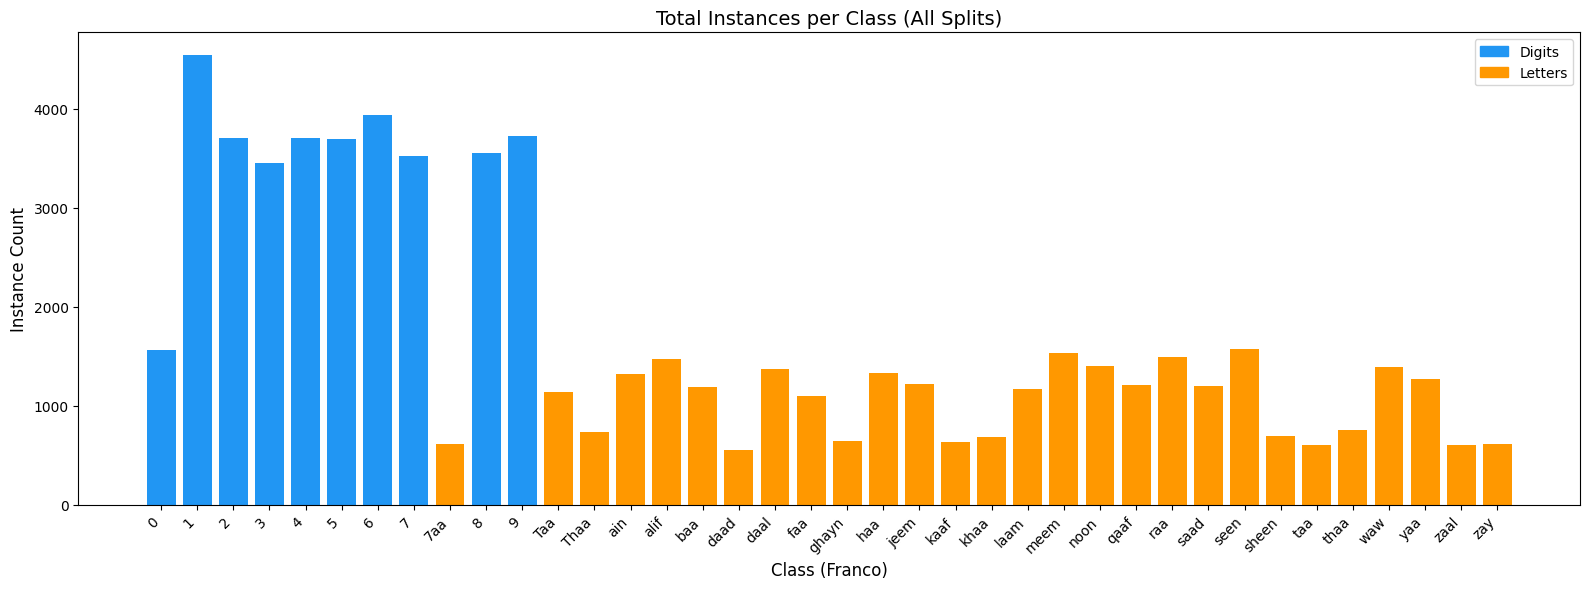

Total instances: 64901
Most common: 1 (4543)
Least common: daad (557)
Imbalance ratio: 8.2x


In [8]:
# Plot: Total instances per class
fig, ax = plt.subplots(figsize=(16, 6))
total_counts = {k: sum(class_counts[s][k] for s in class_counts) for k in CLASS_NAMES}
colors = ['#2196F3' if k.isdigit() else '#FF9800' for k in CLASS_NAMES]
bars = ax.bar(CLASS_NAMES, [total_counts[k] for k in CLASS_NAMES], color=colors)
ax.set_xlabel('Class (Franco)', fontsize=12)
ax.set_ylabel('Instance Count', fontsize=12)
ax.set_title('Total Instances per Class (All Splits)', fontsize=14)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.legend([patches.Patch(color='#2196F3'), patches.Patch(color='#FF9800')],
          ['Digits', 'Letters'])
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'class_counts_total.png'), dpi=150)
plt.show()

print(f"Total instances: {sum(total_counts.values())}")
print(f"Most common: {max(total_counts, key=total_counts.get)} ({max(total_counts.values())})")
print(f"Least common: {min(total_counts, key=total_counts.get)} ({min(total_counts.values())})")
print(f"Imbalance ratio: {max(total_counts.values()) / max(1, min(total_counts.values())):.1f}x")

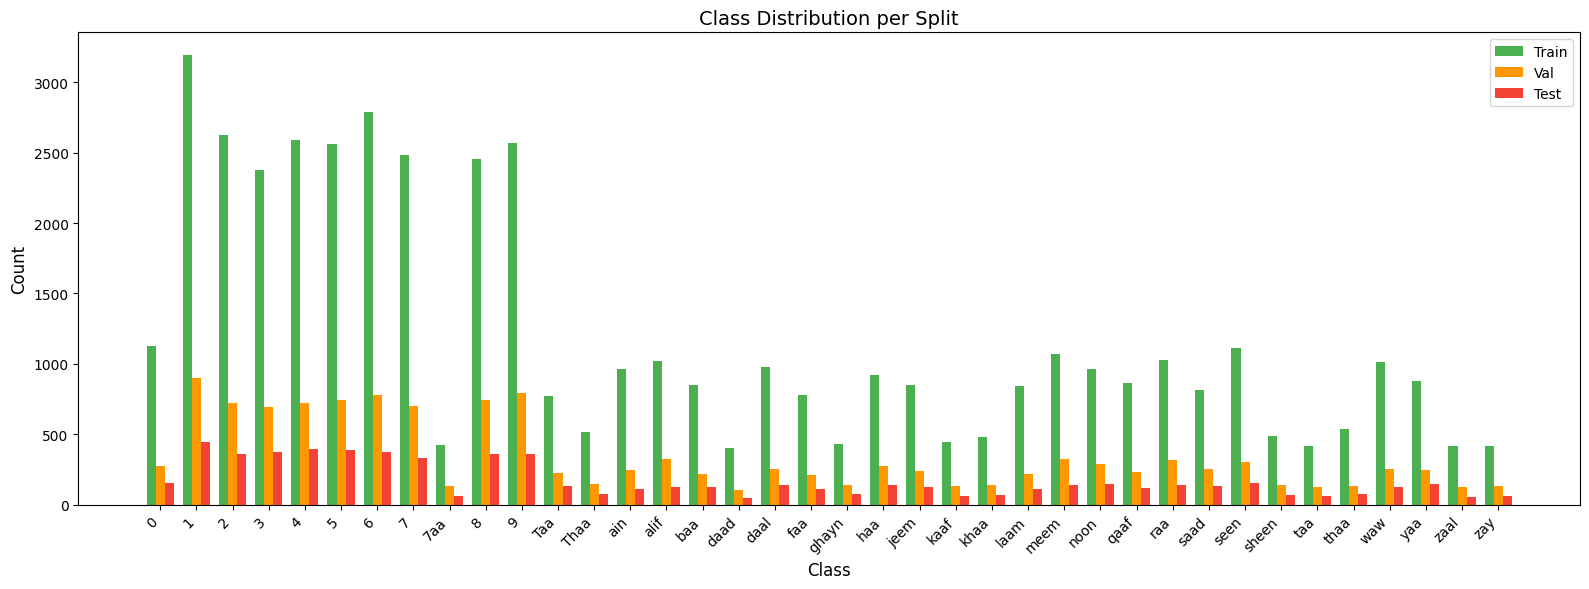

In [9]:
# Plot: Per-split class distribution (stacked bar)
fig, ax = plt.subplots(figsize=(16, 6))
train_vals = [class_counts['train'].get(k, 0) for k in CLASS_NAMES]
val_vals = [class_counts['val'].get(k, 0) for k in CLASS_NAMES]
test_vals = [class_counts['test'].get(k, 0) for k in CLASS_NAMES]

x = np.arange(len(CLASS_NAMES))
w = 0.25
ax.bar(x - w, train_vals, w, label='Train', color='#4CAF50')
ax.bar(x, val_vals, w, label='Val', color='#FF9800')
ax.bar(x + w, test_vals, w, label='Test', color='#F44336')
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Class Distribution per Split', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'class_counts_per_split.png'), dpi=150)
plt.show()

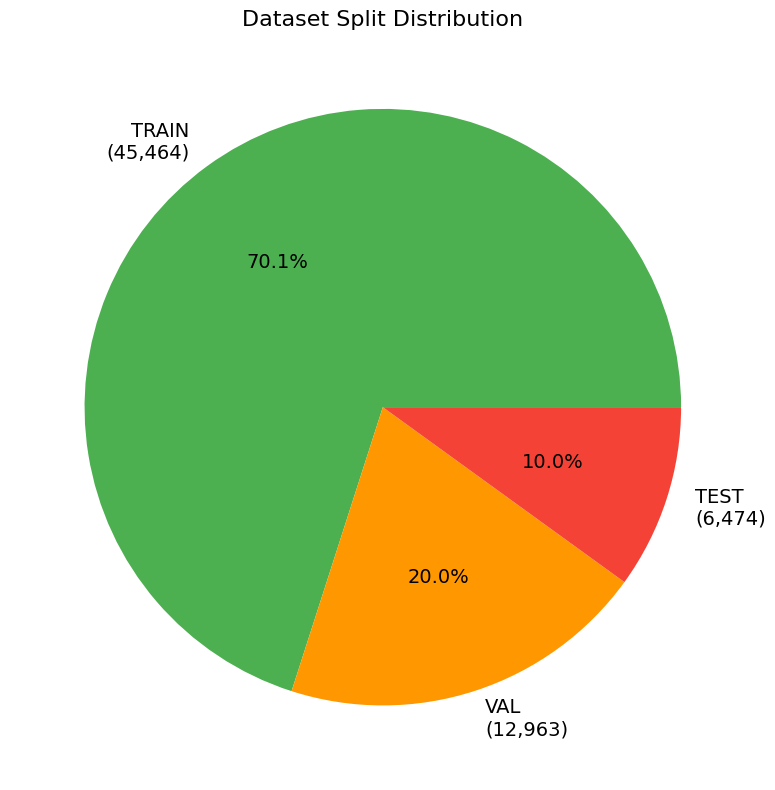

In [10]:
# Plot: Split sizes pie chart
split_totals = {s: sum(class_counts[s].values()) for s in class_counts}
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(split_totals.values(), labels=[f"{s.upper()}\n({v:,})" for s, v in split_totals.items()],
        autopct='%1.1f%%', colors=['#4CAF50', '#FF9800', '#F44336'],
        textprops={'fontsize': 14})
ax.set_title('Dataset Split Distribution', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'split_pie.png'), dpi=150)
plt.show()

In [11]:
# Analyze image dimensions and bounding box sizes
img_sizes = []
bbox_sizes = []
bbox_aspect_ratios = []
instances_per_img = []

for split in ["train", "val", "test"]:
    img_dir = os.path.join(DATASET_DIR, split, "images")
    lbl_dir = os.path.join(DATASET_DIR, split, "labels")
    if not os.path.exists(img_dir):
        continue
    for img_path in glob.glob(os.path.join(img_dir, "*.*"))[:500]:
        img = Image.open(img_path)
        img_sizes.append(img.size)  # (w, h)
        lbl_path = os.path.join(lbl_dir, Path(img_path).stem + ".txt")
        if not os.path.exists(lbl_path):
            continue
        count = 0
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    bw, bh = float(parts[3]), float(parts[4])
                    bbox_sizes.append(bw * bh)  # area (normalized)
                    bbox_aspect_ratios.append(bw / max(bh, 0.001))
                    count += 1
        instances_per_img.append(count)

print(f"Analyzed {len(img_sizes)} images")

Analyzed 1500 images


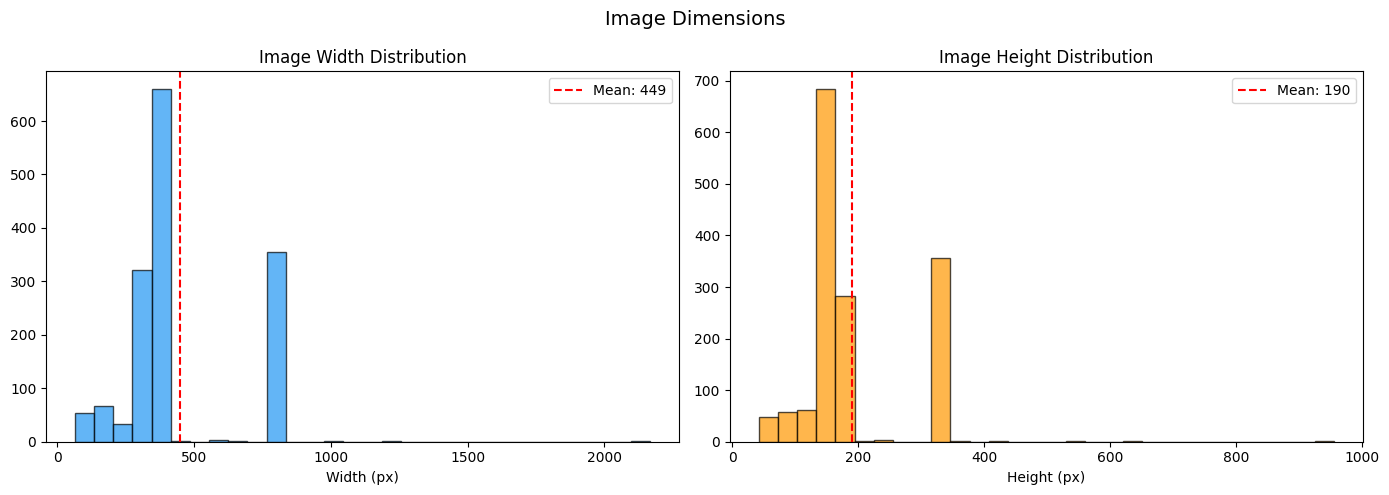

In [12]:
# Plot: Image dimensions distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
widths = [s[0] for s in img_sizes]
heights = [s[1] for s in img_sizes]
axes[0].hist(widths, bins=30, color='#2196F3', alpha=0.7, edgecolor='black')
axes[0].set_title('Image Width Distribution')
axes[0].set_xlabel('Width (px)')
axes[0].axvline(np.mean(widths), color='red', linestyle='--', label=f'Mean: {np.mean(widths):.0f}')
axes[0].legend()

axes[1].hist(heights, bins=30, color='#FF9800', alpha=0.7, edgecolor='black')
axes[1].set_title('Image Height Distribution')
axes[1].set_xlabel('Height (px)')
axes[1].axvline(np.mean(heights), color='red', linestyle='--', label=f'Mean: {np.mean(heights):.0f}')
axes[1].legend()

plt.suptitle('Image Dimensions', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'image_dimensions.png'), dpi=150)
plt.show()

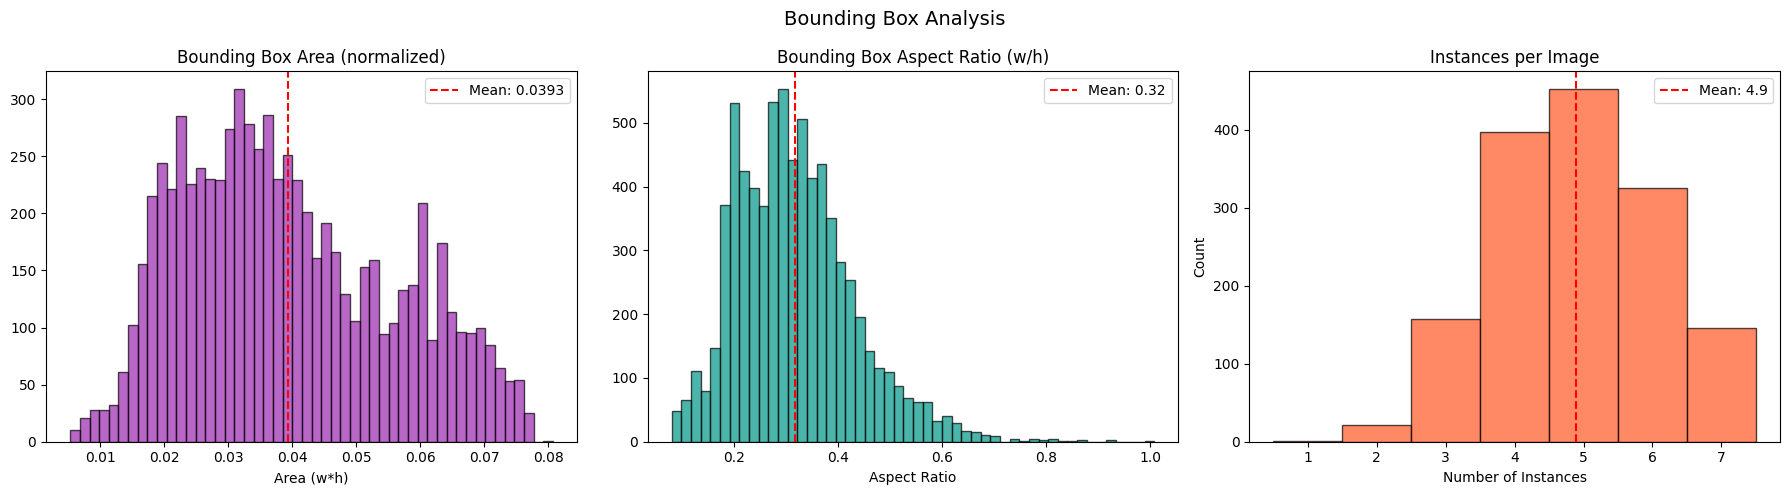

In [13]:
# Plot: Bounding box sizes and aspect ratios
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(bbox_sizes, bins=50, color='#9C27B0', alpha=0.7, edgecolor='black')
axes[0].set_title('Bounding Box Area (normalized)')
axes[0].set_xlabel('Area (w*h)')
axes[0].axvline(np.mean(bbox_sizes), color='red', linestyle='--', label=f'Mean: {np.mean(bbox_sizes):.4f}')
axes[0].legend()

axes[1].hist(bbox_aspect_ratios, bins=50, color='#009688', alpha=0.7, edgecolor='black')
axes[1].set_title('Bounding Box Aspect Ratio (w/h)')
axes[1].set_xlabel('Aspect Ratio')
axes[1].axvline(np.mean(bbox_aspect_ratios), color='red', linestyle='--', label=f'Mean: {np.mean(bbox_aspect_ratios):.2f}')
axes[1].legend()

axes[2].hist(instances_per_img, bins=range(1, max(instances_per_img)+2), 
             color='#FF5722', alpha=0.7, edgecolor='black', align='left')
axes[2].set_title('Instances per Image')
axes[2].set_xlabel('Number of Instances')
axes[2].set_ylabel('Count')
axes[2].axvline(np.mean(instances_per_img), color='red', linestyle='--', 
                label=f'Mean: {np.mean(instances_per_img):.1f}')
axes[2].legend()

plt.suptitle('Bounding Box Analysis', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'bbox_analysis.png'), dpi=150)
plt.show()

## 4. Sample Images with Annotations

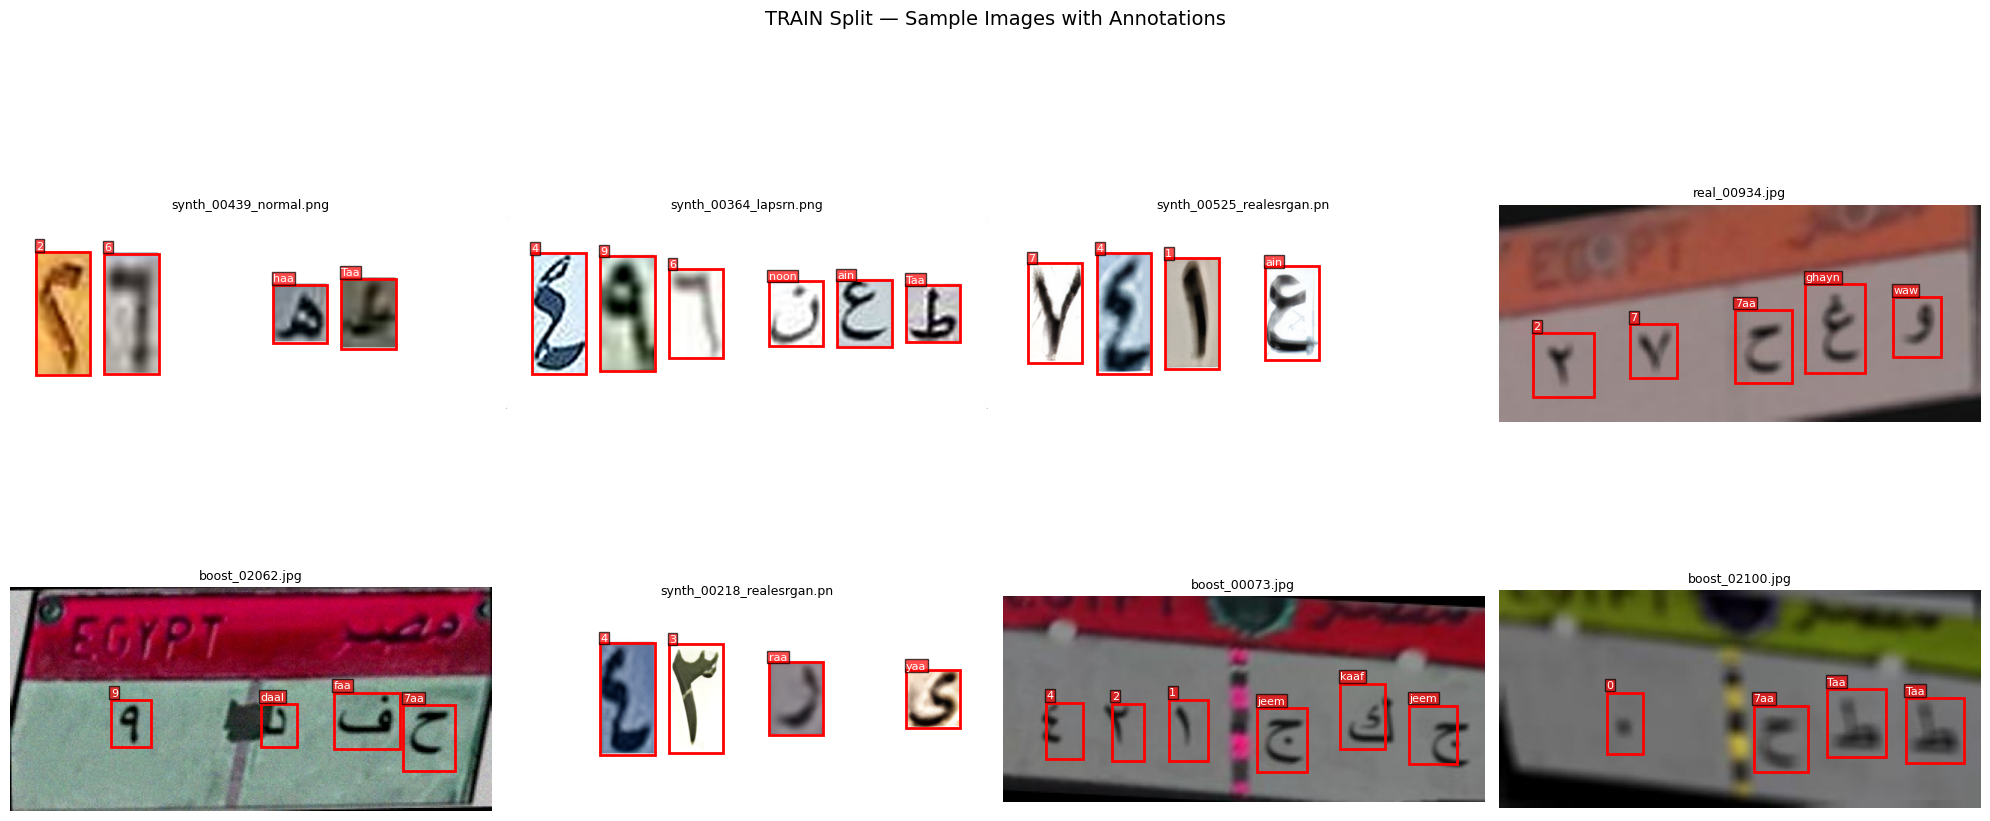

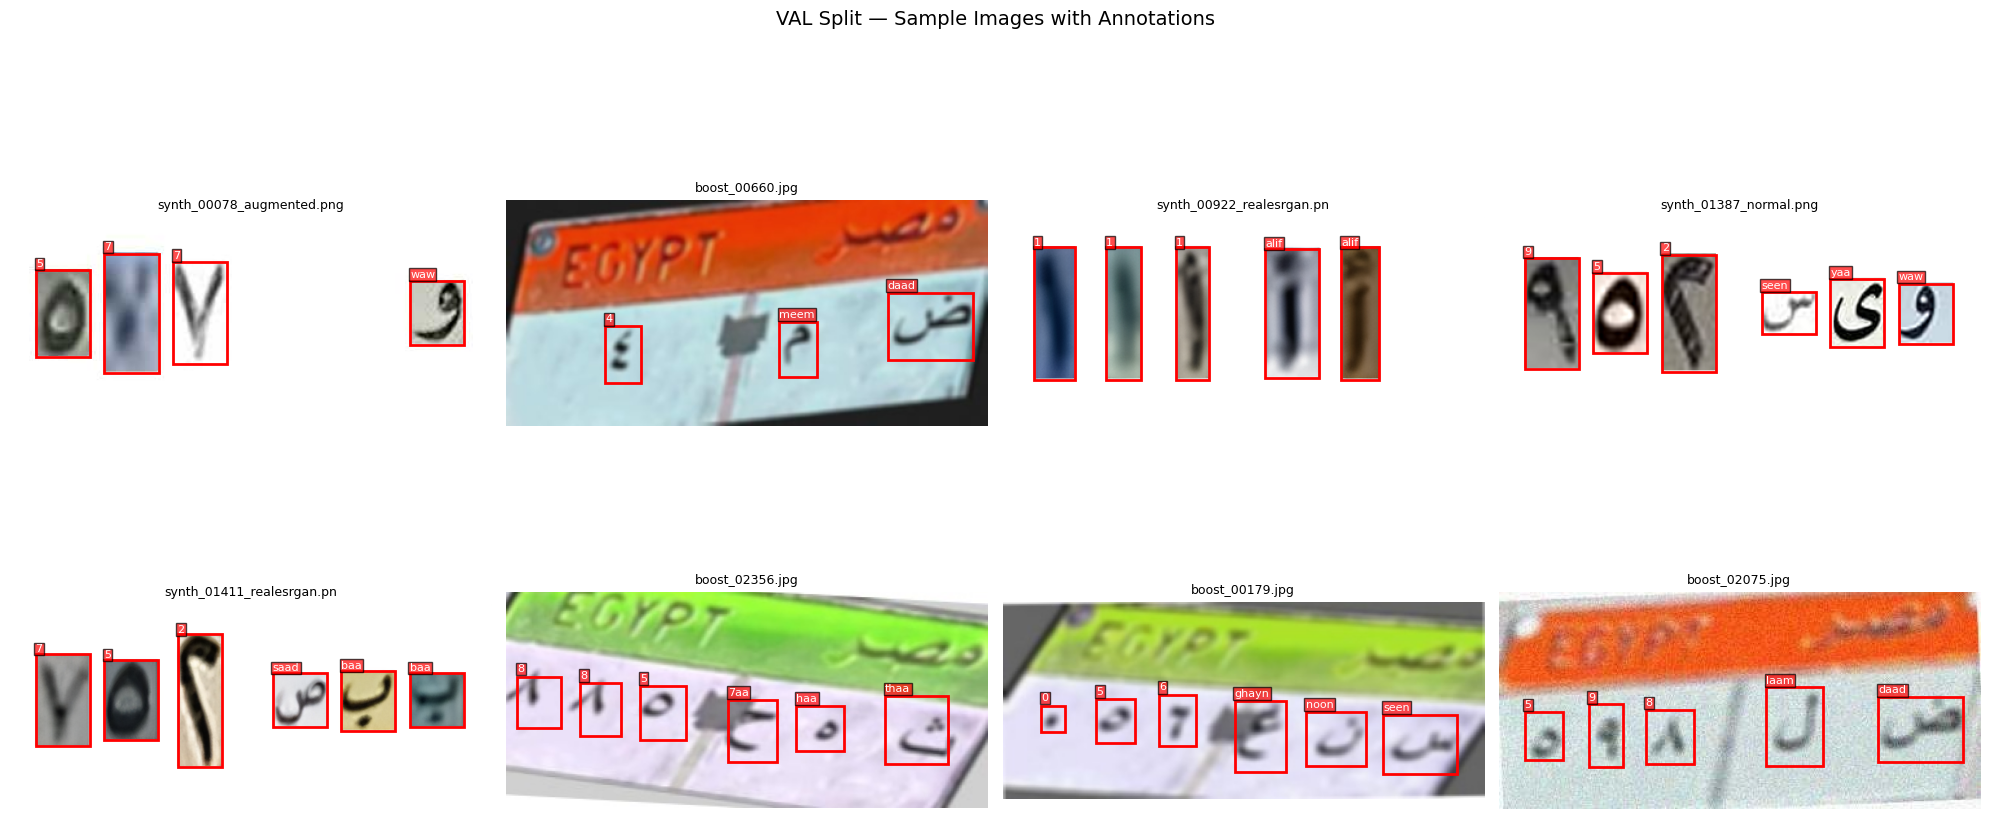

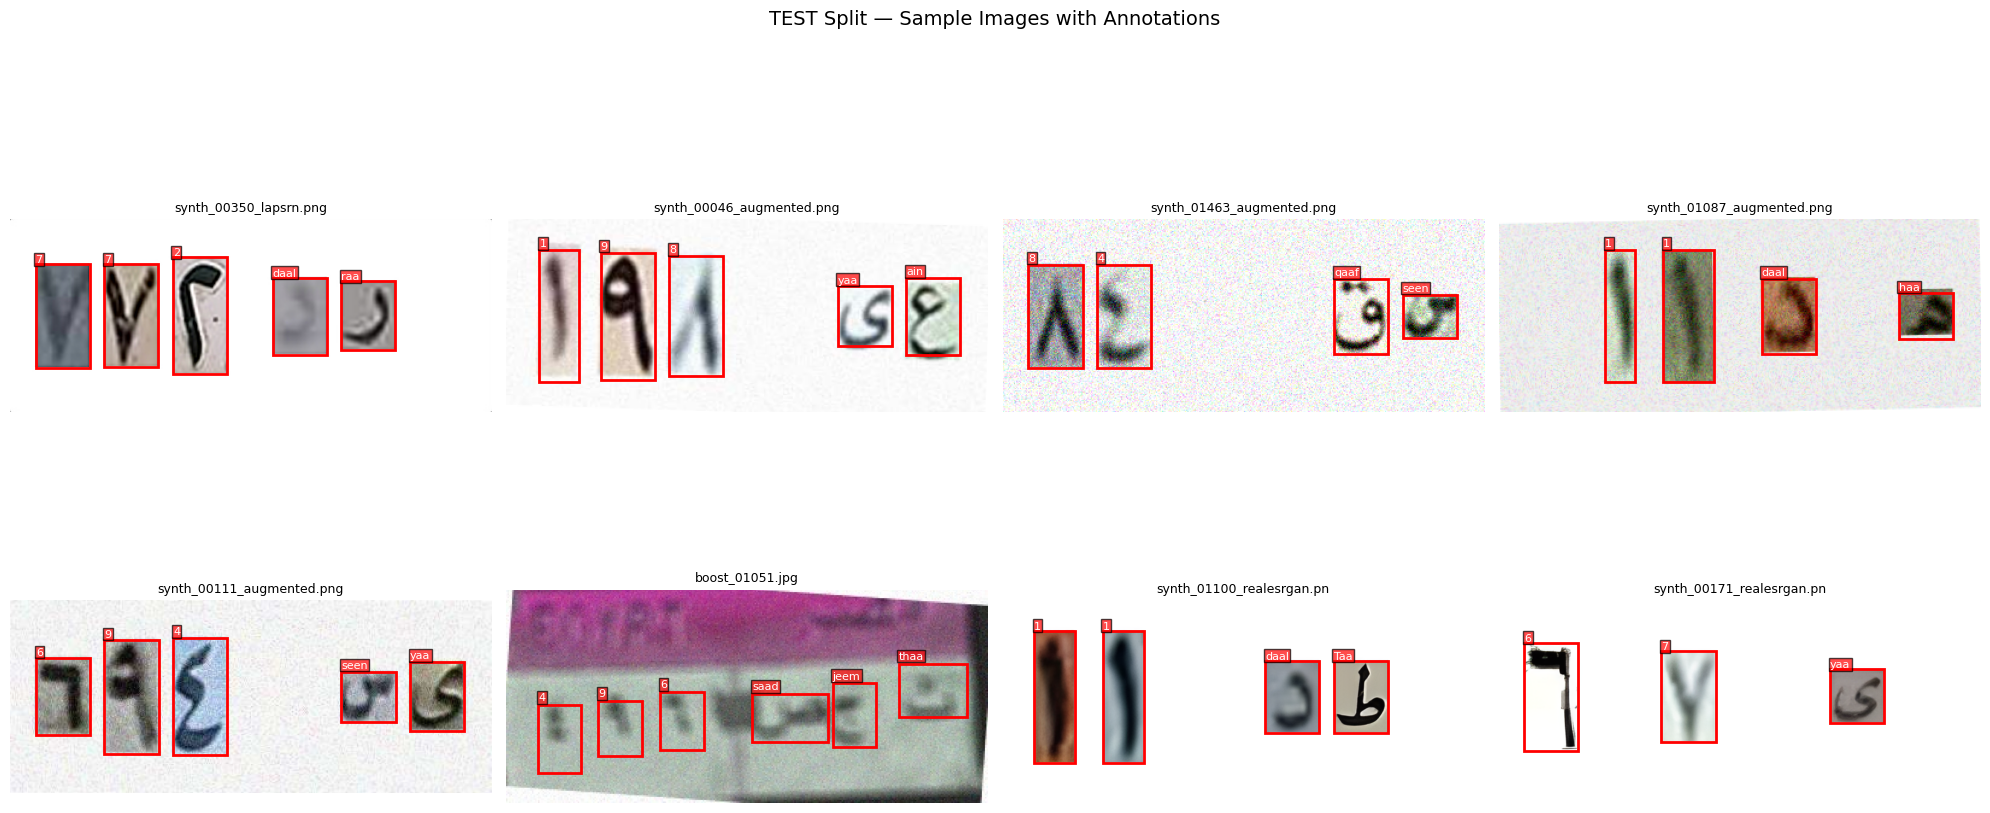

In [14]:
def plot_sample_images(dataset_dir, split, class_names, n_samples=8, seed=42):
    """Show sample images with YOLO bounding boxes and class labels."""
    img_dir = os.path.join(dataset_dir, split, "images")
    lbl_dir = os.path.join(dataset_dir, split, "labels")
    if not os.path.exists(img_dir):
        print(f"{split} split not found")
        return

    img_files = glob.glob(os.path.join(img_dir, "*.*"))
    random.seed(seed)
    samples = random.sample(img_files, min(n_samples, len(img_files)))

    cols = 4
    rows = (len(samples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
    axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes.flatten()

    for idx, (ax, img_path) in enumerate(zip(axes, samples)):
        img = Image.open(img_path)
        ax.imshow(np.array(img), cmap='gray' if img.mode == 'L' else None)
        
        lbl_path = os.path.join(lbl_dir, Path(img_path).stem + ".txt")
        if os.path.exists(lbl_path):
            iw, ih = img.size
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cid, xc, yc, bw, bh = int(parts[0]), *[float(p) for p in parts[1:6]]
                    x1 = (xc - bw / 2) * iw
                    y1 = (yc - bh / 2) * ih
                    w = bw * iw
                    h = bh * ih
                    rect = patches.Rectangle((x1, y1), w, h, linewidth=2,
                                            edgecolor='red', facecolor='none')
                    ax.add_patch(rect)
                    label = class_names[cid] if cid < len(class_names) else str(cid)
                    ax.text(x1, y1 - 3, label, fontsize=8, color='white',
                           bbox=dict(facecolor='red', alpha=0.7, pad=1))
        
        ax.set_title(Path(img_path).name[:25], fontsize=9)
        ax.axis('off')

    for ax in axes[len(samples):]:
        ax.axis('off')

    plt.suptitle(f'{split.upper()} Split — Sample Images with Annotations', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(WORK_DIR, f'samples_{split}.png'), dpi=150, bbox_inches='tight')
    plt.show()

# Show samples from each split
for split in ["train", "val", "test"]:
    plot_sample_images(DATASET_DIR, split, CLASS_NAMES, n_samples=8)

## 5. Training — YOLO26m Fine-Tuning

In [15]:
# Load pretrained YOLO26m
model = YOLO("yolo26m.pt")
print(f"Model: {model.model_name}")
print(f"Parameters: {sum(p.numel() for p in model.model.parameters()):,}")

Model: yolo26m.pt
Parameters: 21,896,248


In [16]:
# Training configuration — NO class weighting
TRAIN_CONFIG = {
    "data": yaml_path,
    "epochs": 100,
    "imgsz": 640,
    "batch": 16,           # T4 can handle 16 at 640
    "device": 0,           # GPU
    "workers": 2,          # Kaggle has limited workers
    "seed": SEED,
    "project": WORK_DIR + "/runs",
    "name": "yolo26m_ocr_V2",
    "pretrained": True,
    "optimizer": "AdamW",
    "lr0": 0.01,
    "lrf": 0.01,
    "warmup_epochs": 3,
    "patience": 12,        # early stopping patience
    "save": True,
    "save_period": 10,     # save checkpoint every 10 epochs
    "plots": True,
    "val": True,
    # Augmentation
    "hsv_h": 0.015,
    "hsv_s": 0.7,
    "hsv_v": 0.4,
    "degrees": 5.0,         # rotation for plate angle variation
    "translate": 0.1,
    "scale": 0.5,
    "fliplr": 0.0,         # don't flip Arabic characters!
    "mosaic": 1.0,
    "mixup": 0.1,
    "close_mosaic": 10,    # disable mosaic for last 10 epochs
}

print("Training config:")
for k, v in TRAIN_CONFIG.items():
    print(f"  {k}: {v}")

Training config:
  data: /kaggle/working/data.yaml
  epochs: 100
  imgsz: 640
  batch: 16
  device: 0
  workers: 2
  seed: 42
  project: /kaggle/working/runs
  name: yolo26m_ocr_V2
  pretrained: True
  optimizer: AdamW
  lr0: 0.01
  lrf: 0.01
  warmup_epochs: 3
  patience: 12
  save: True
  save_period: 10
  plots: True
  val: True
  hsv_h: 0.015
  hsv_s: 0.7
  hsv_v: 0.4
  degrees: 5.0
  translate: 0.1
  scale: 0.5
  fliplr: 0.0
  mosaic: 1.0
  mixup: 0.1
  close_mosaic: 10


In [17]:
# Run training
results = model.train(**TRAIN_CONFIG)

Ultralytics 8.4.49 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26m_ocr_V2, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=

KeyboardInterrupt: 

## 6. Training Results & Metrics

In [18]:
# Load best model
best_model_path = os.path.join(WORK_DIR, "runs", "yolo26m_ocr_V2", "weights", "best.pt")
best_model = YOLO(best_model_path)
print(f"Best model: {best_model_path}")
print(f"File size: {os.path.getsize(best_model_path) / 1e6:.1f} MB")

Best model: /kaggle/working/runs/yolo26m_ocr_V2/weights/best.pt
File size: 175.5 MB



  labels.jpg


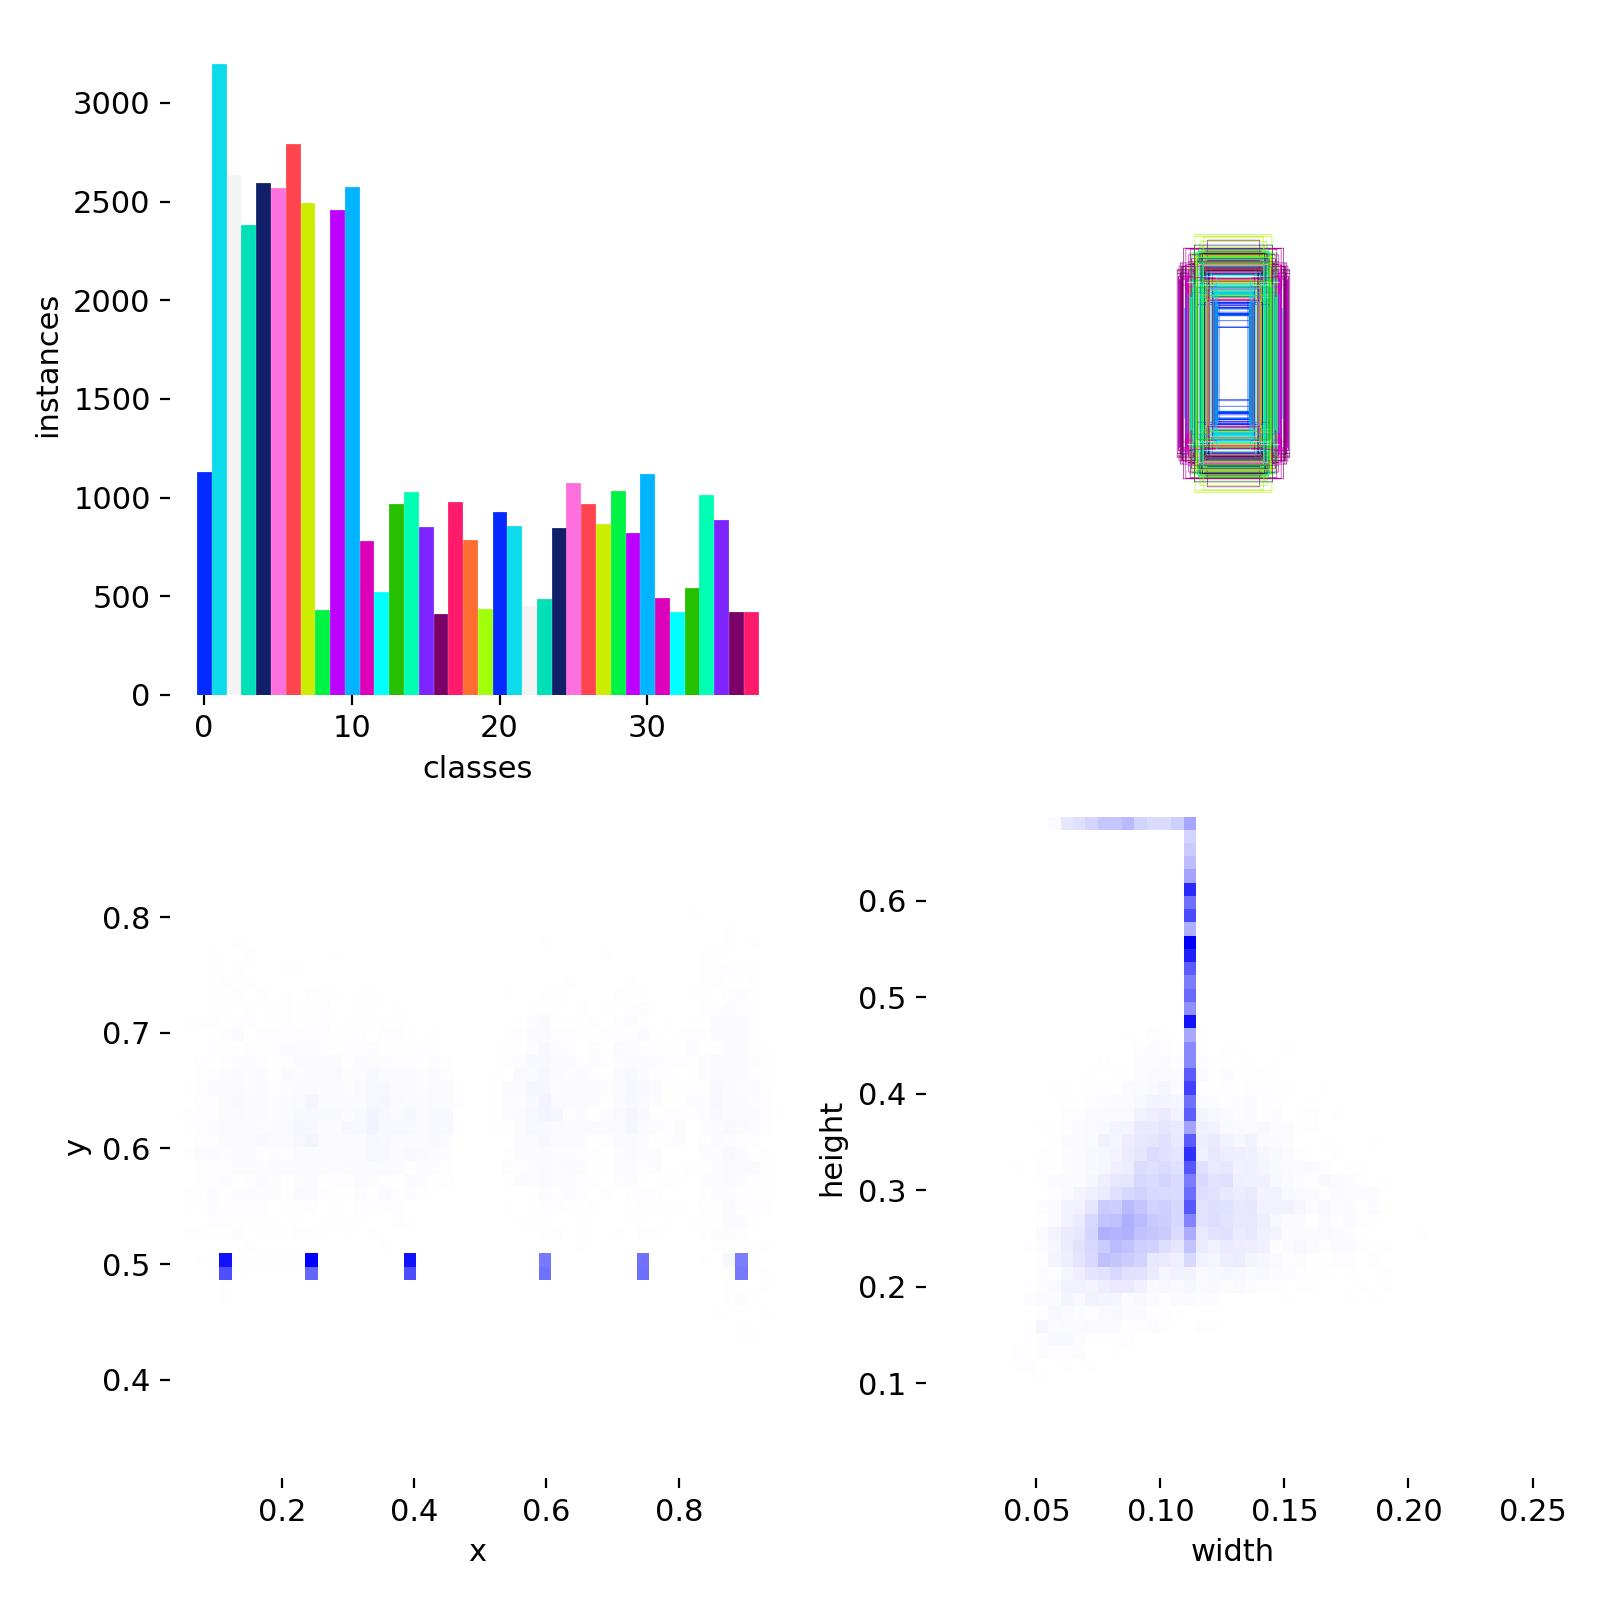

  Saved to presentation_outputs/labels.jpg

  Extra: train_batch1.jpg


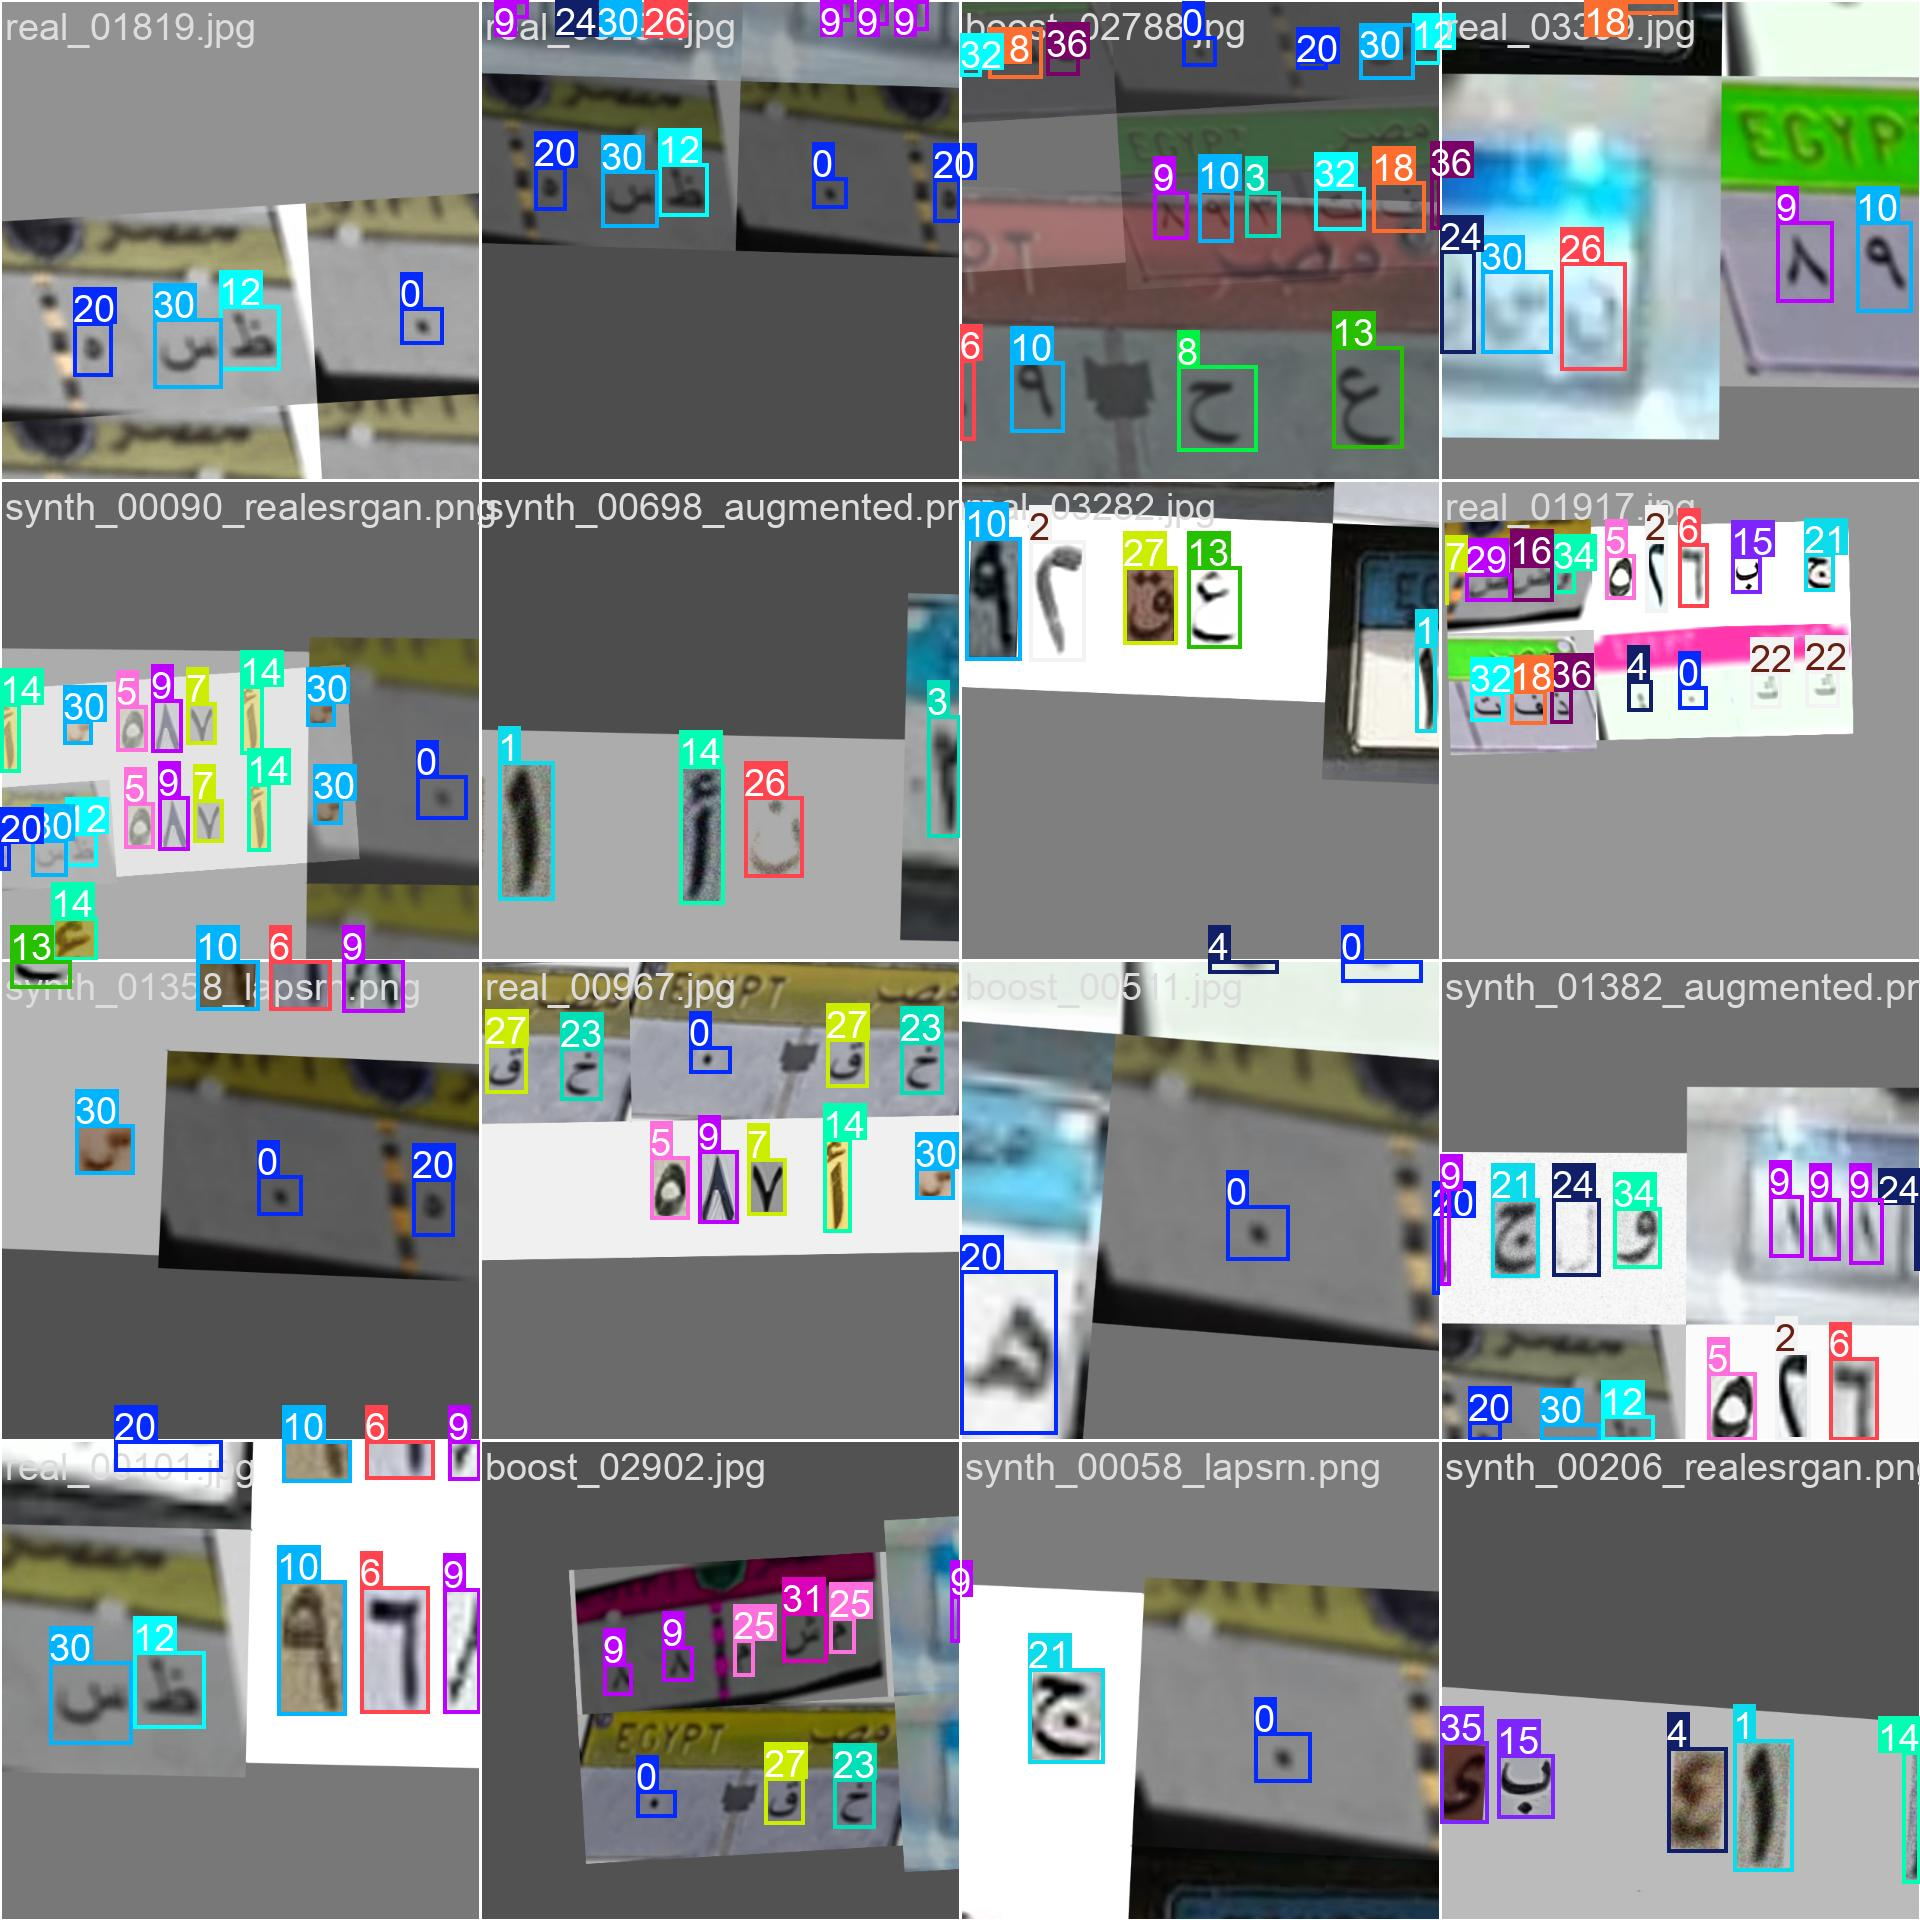


  Extra: train_batch2.jpg


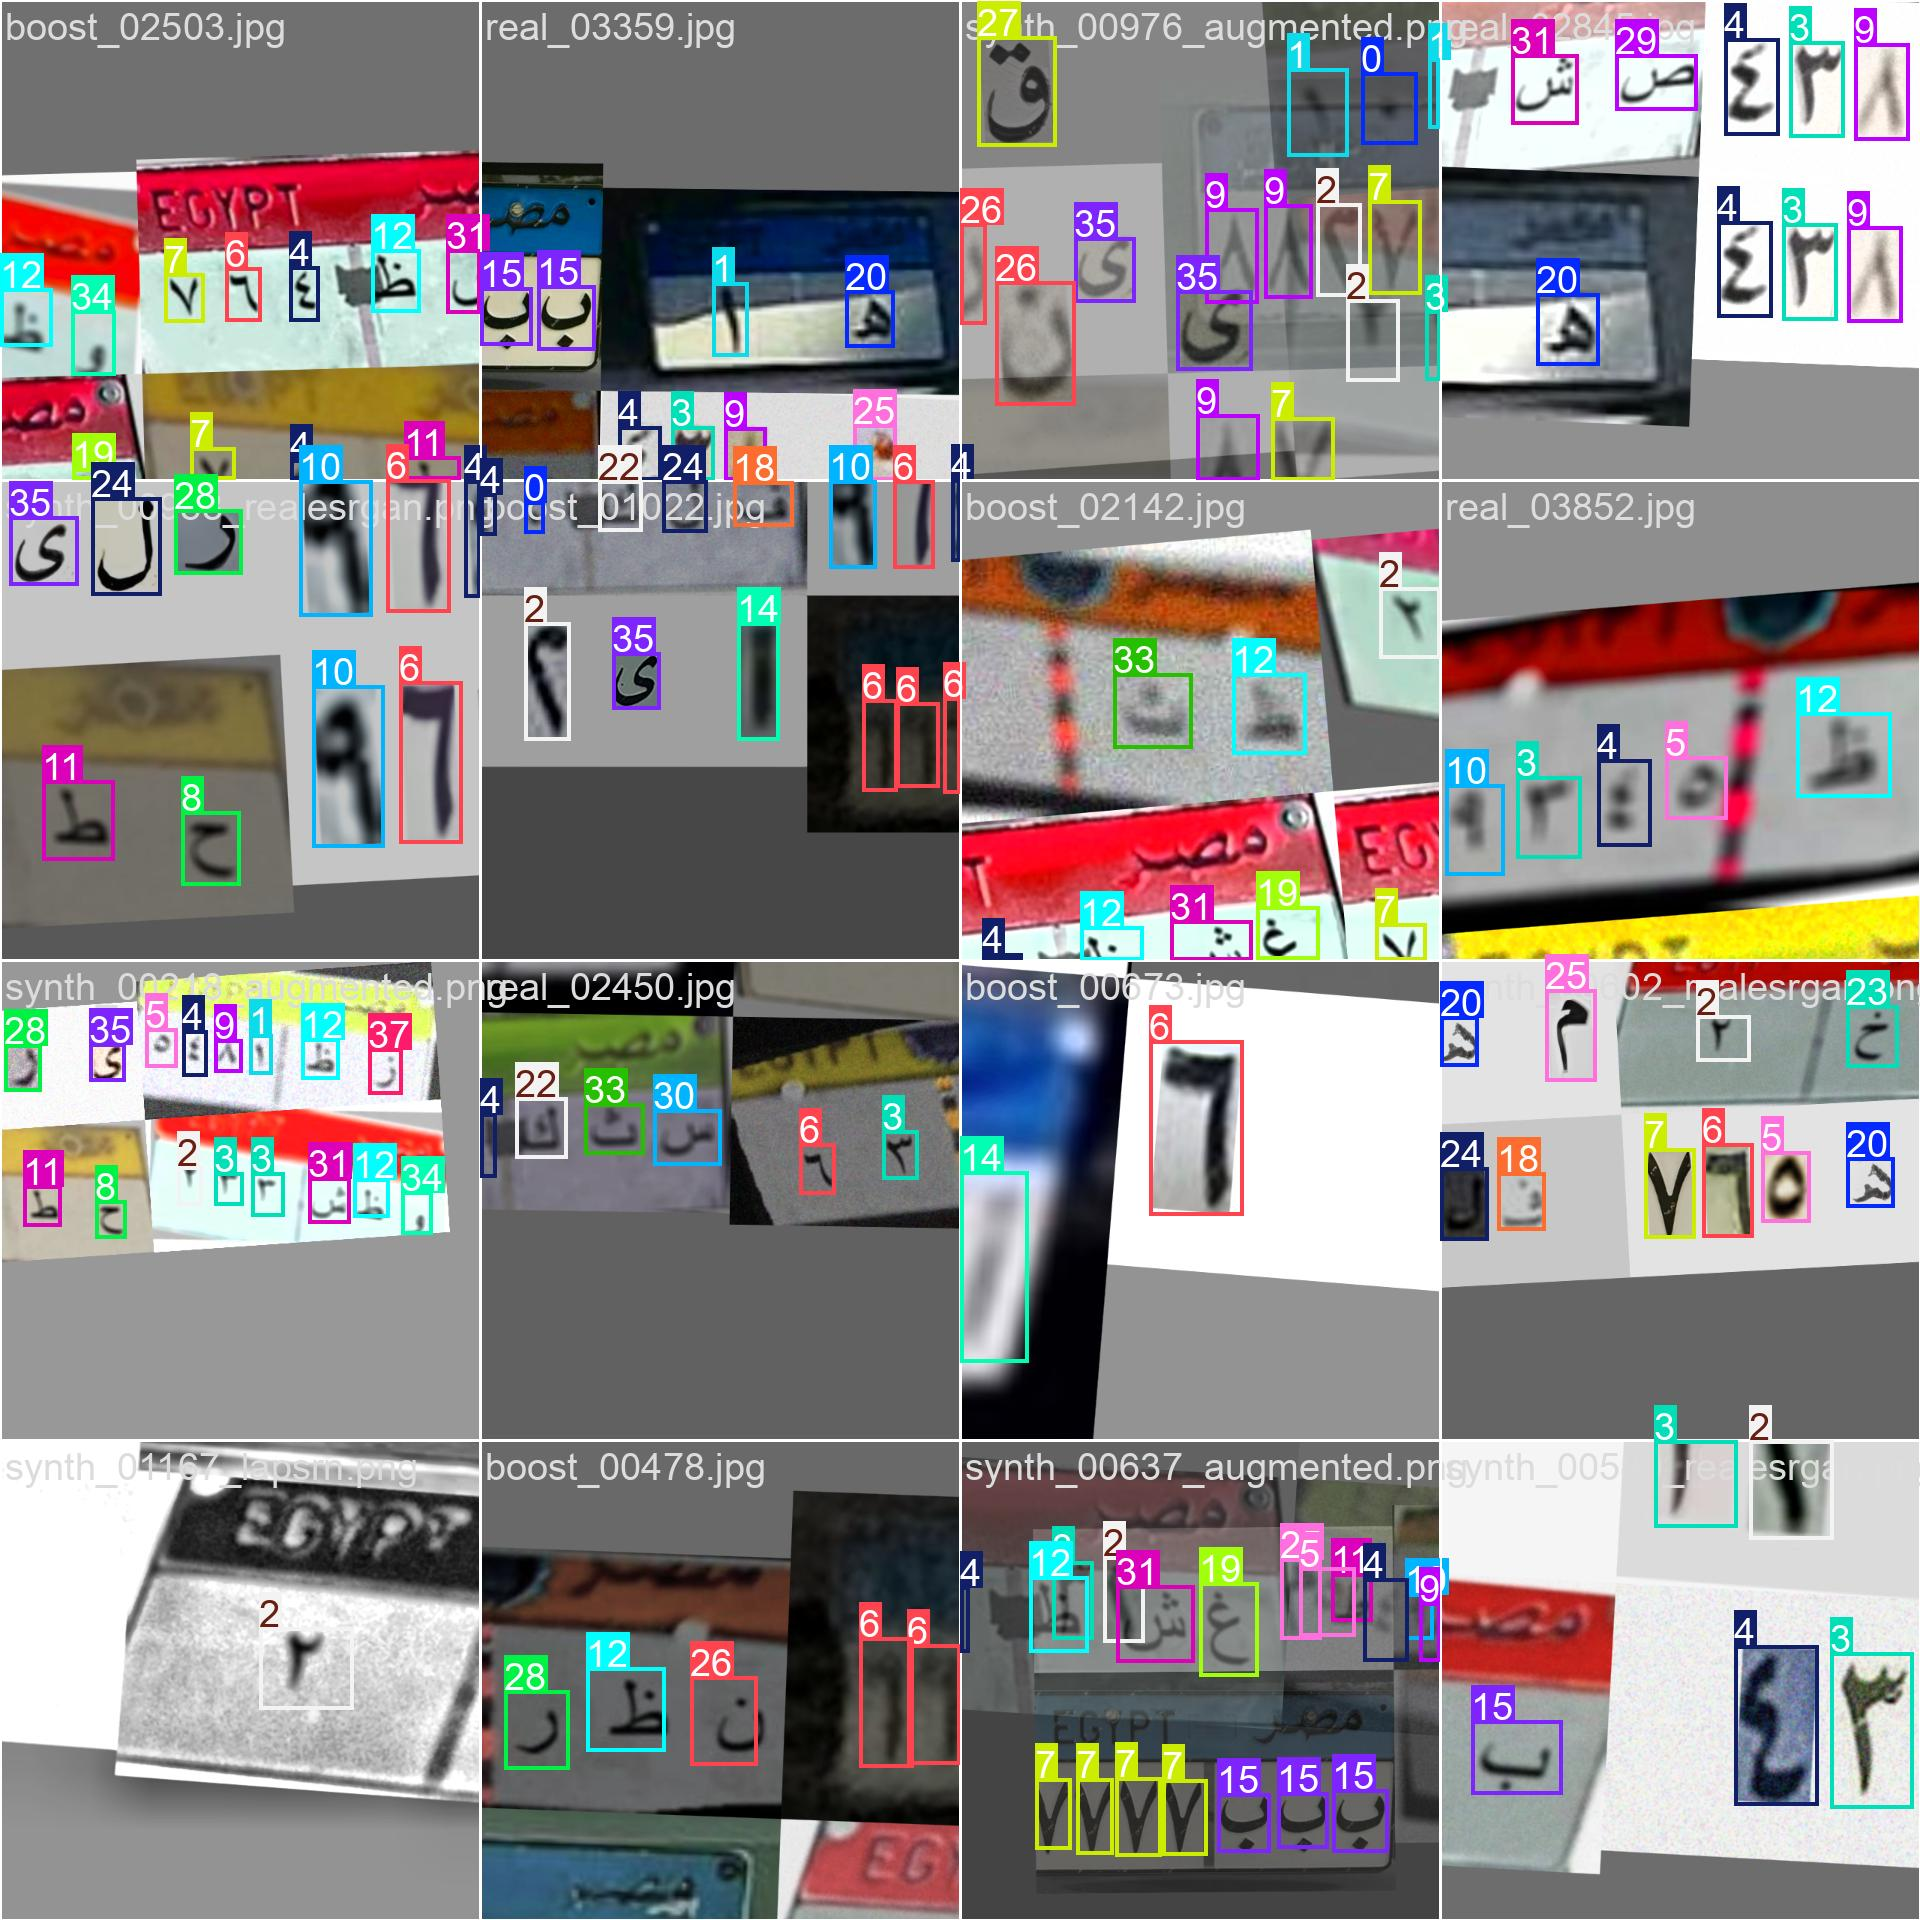


  Extra: train_batch0.jpg


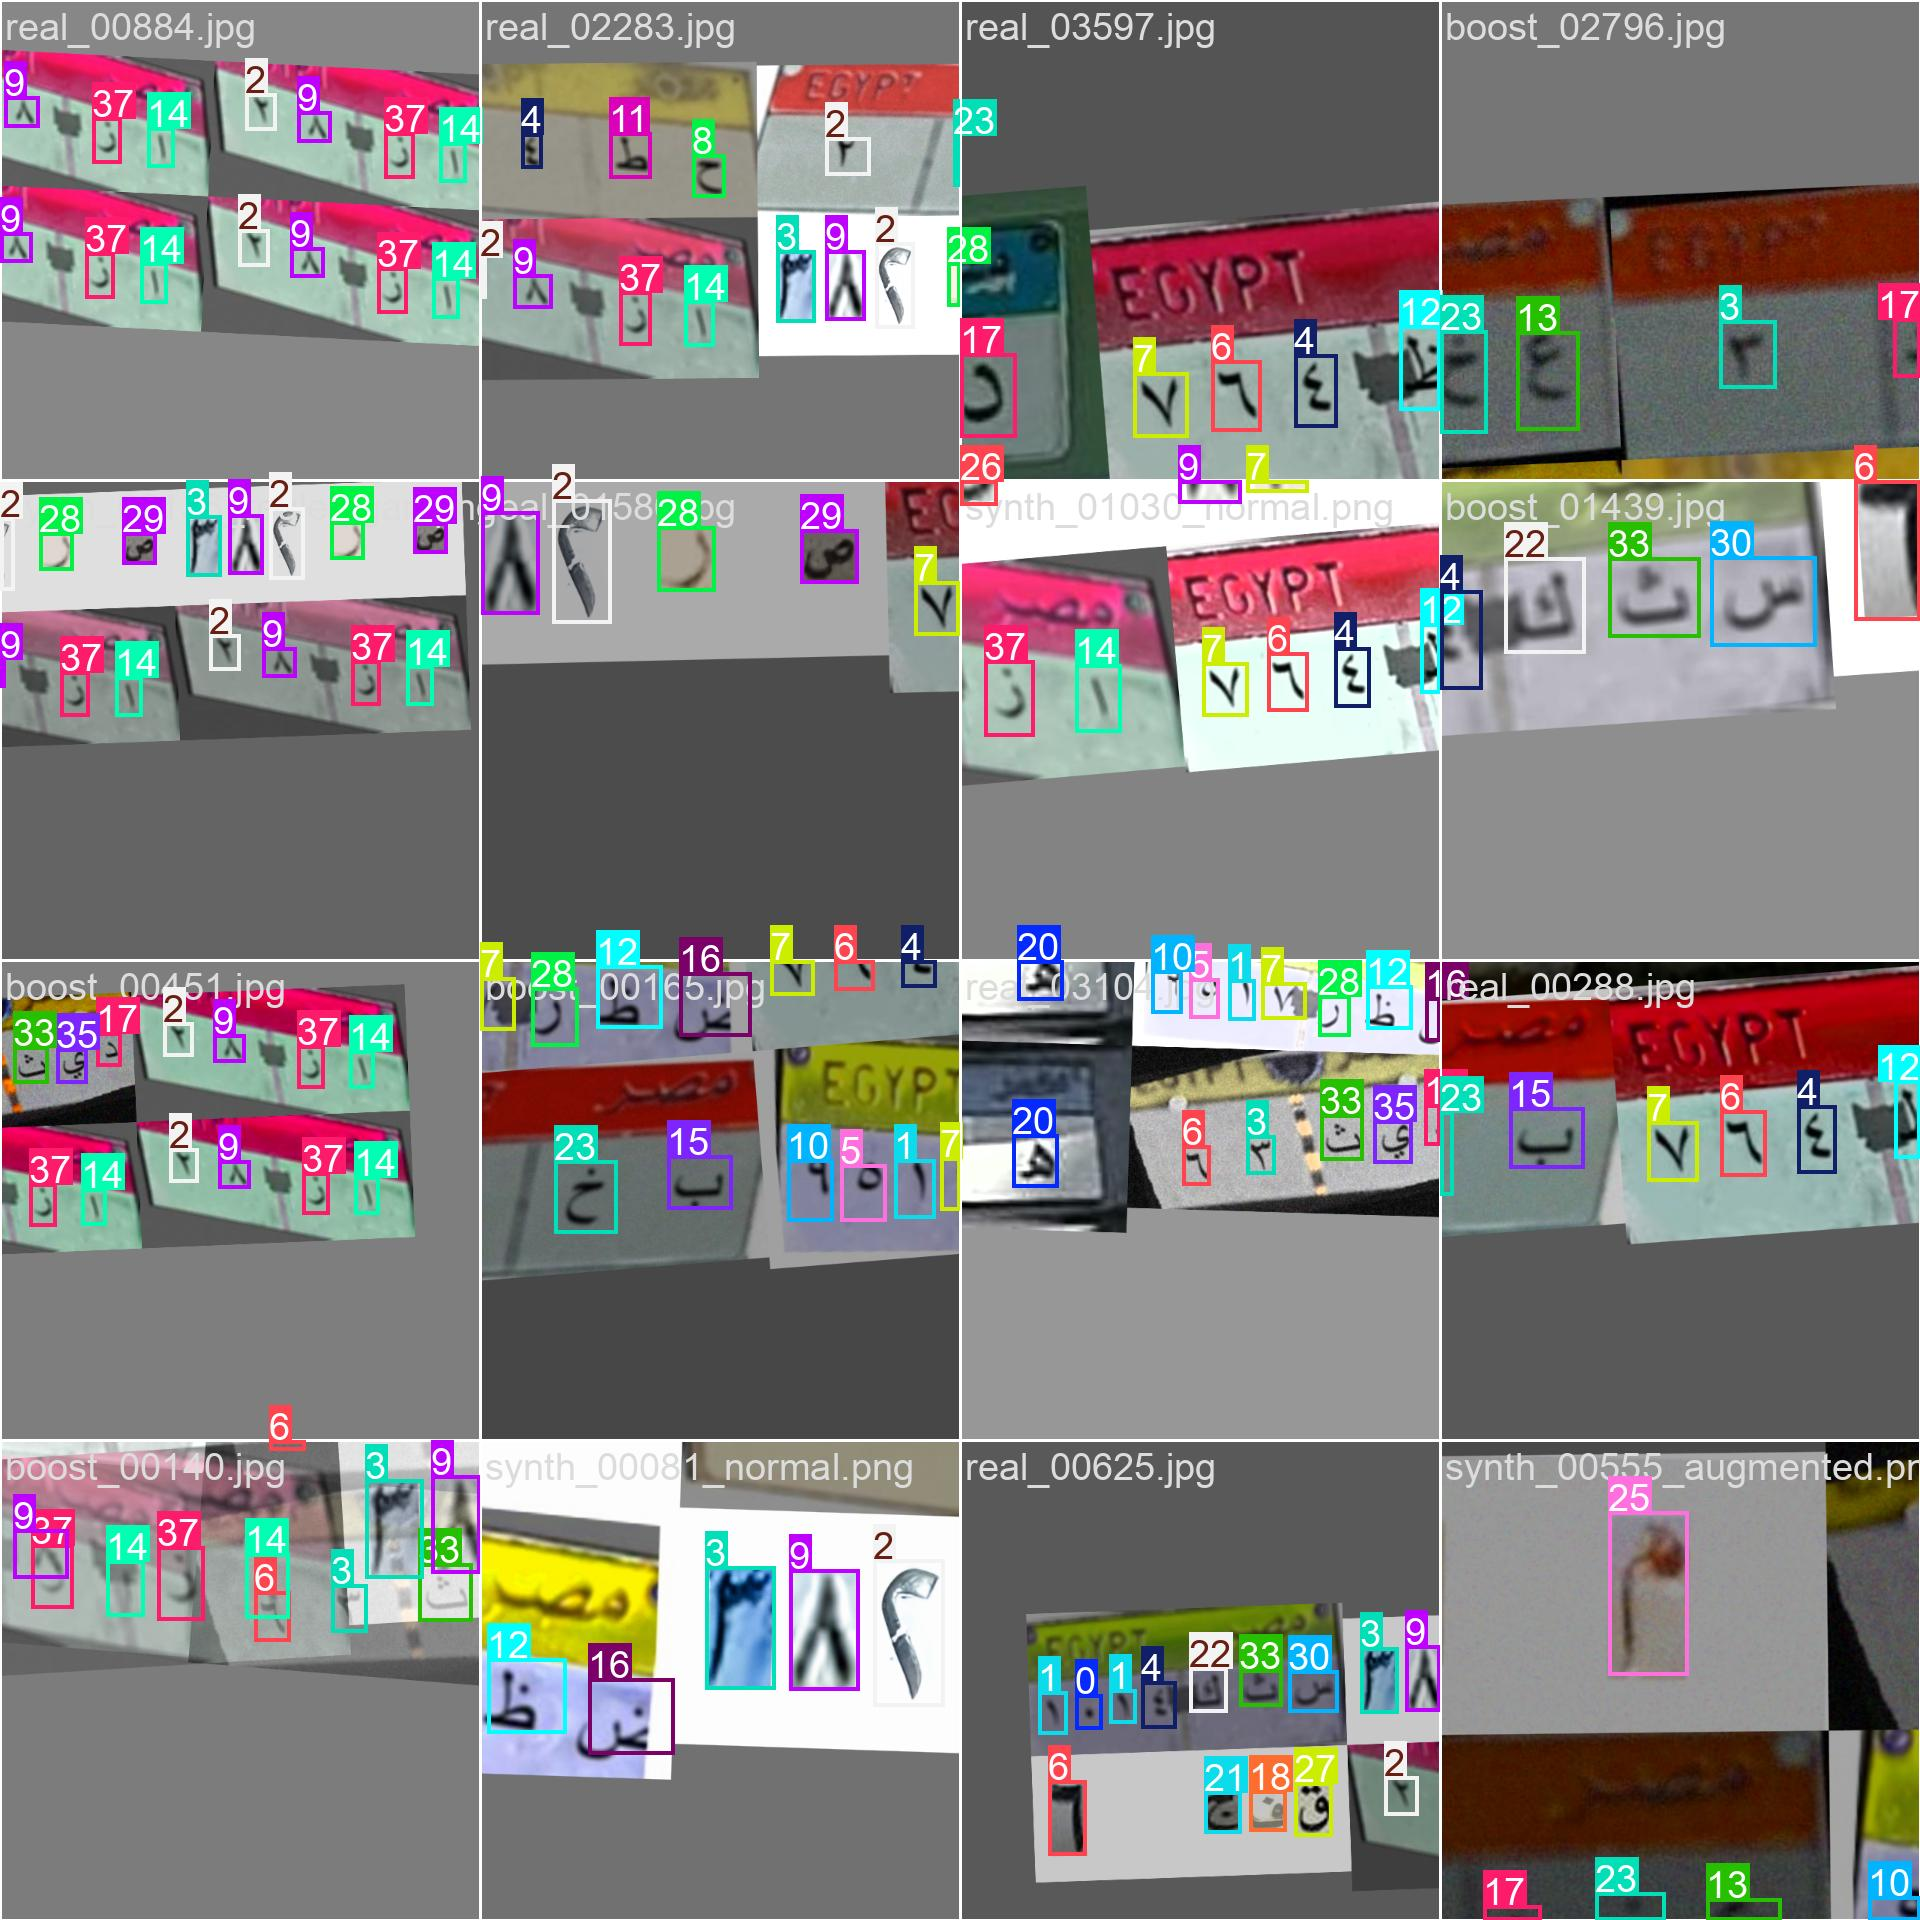


All presentation images saved to: /kaggle/working/presentation_outputs
Download this folder for your presentation.


In [19]:
# Plot training curves (generated by ultralytics)
from IPython.display import Image as IPImage, display
import shutil

results_dir = os.path.join(WORK_DIR, "runs", "yolo26m_ocr_V2")

# Create presentation output folder
presentation_dir = os.path.join(WORK_DIR, "presentation_outputs")
os.makedirs(presentation_dir, exist_ok=True)

# Display and save ALL ultralytics output images
ultralytics_images = [
    "results.png", "confusion_matrix.png", "confusion_matrix_normalized.png",
    "labels.jpg", "labels_correlogram.jpg",
    "P_curve.png", "R_curve.png", "PR_curve.png", "F1_curve.png",
    "BoxPR_curve.png",
]

for chart in ultralytics_images:
    path = os.path.join(results_dir, chart)
    if os.path.exists(path):
        print(f"\n{'='*60}")
        print(f"  {chart}")
        print(f"{'='*60}")
        display(IPImage(filename=path))
        # Copy to presentation folder
        shutil.copy2(path, os.path.join(presentation_dir, chart))
        print(f"  Saved to presentation_outputs/{chart}")

# Also check for any additional images in the results dir
for ext in ["*.png", "*.jpg"]:
    for f in glob.glob(os.path.join(results_dir, ext)):
        fname = os.path.basename(f)
        if fname not in ultralytics_images:
            print(f"\n  Extra: {fname}")
            display(IPImage(filename=f))
            shutil.copy2(f, os.path.join(presentation_dir, f"extra_{fname}"))

print(f"\nAll presentation images saved to: {presentation_dir}")
print("Download this folder for your presentation.")


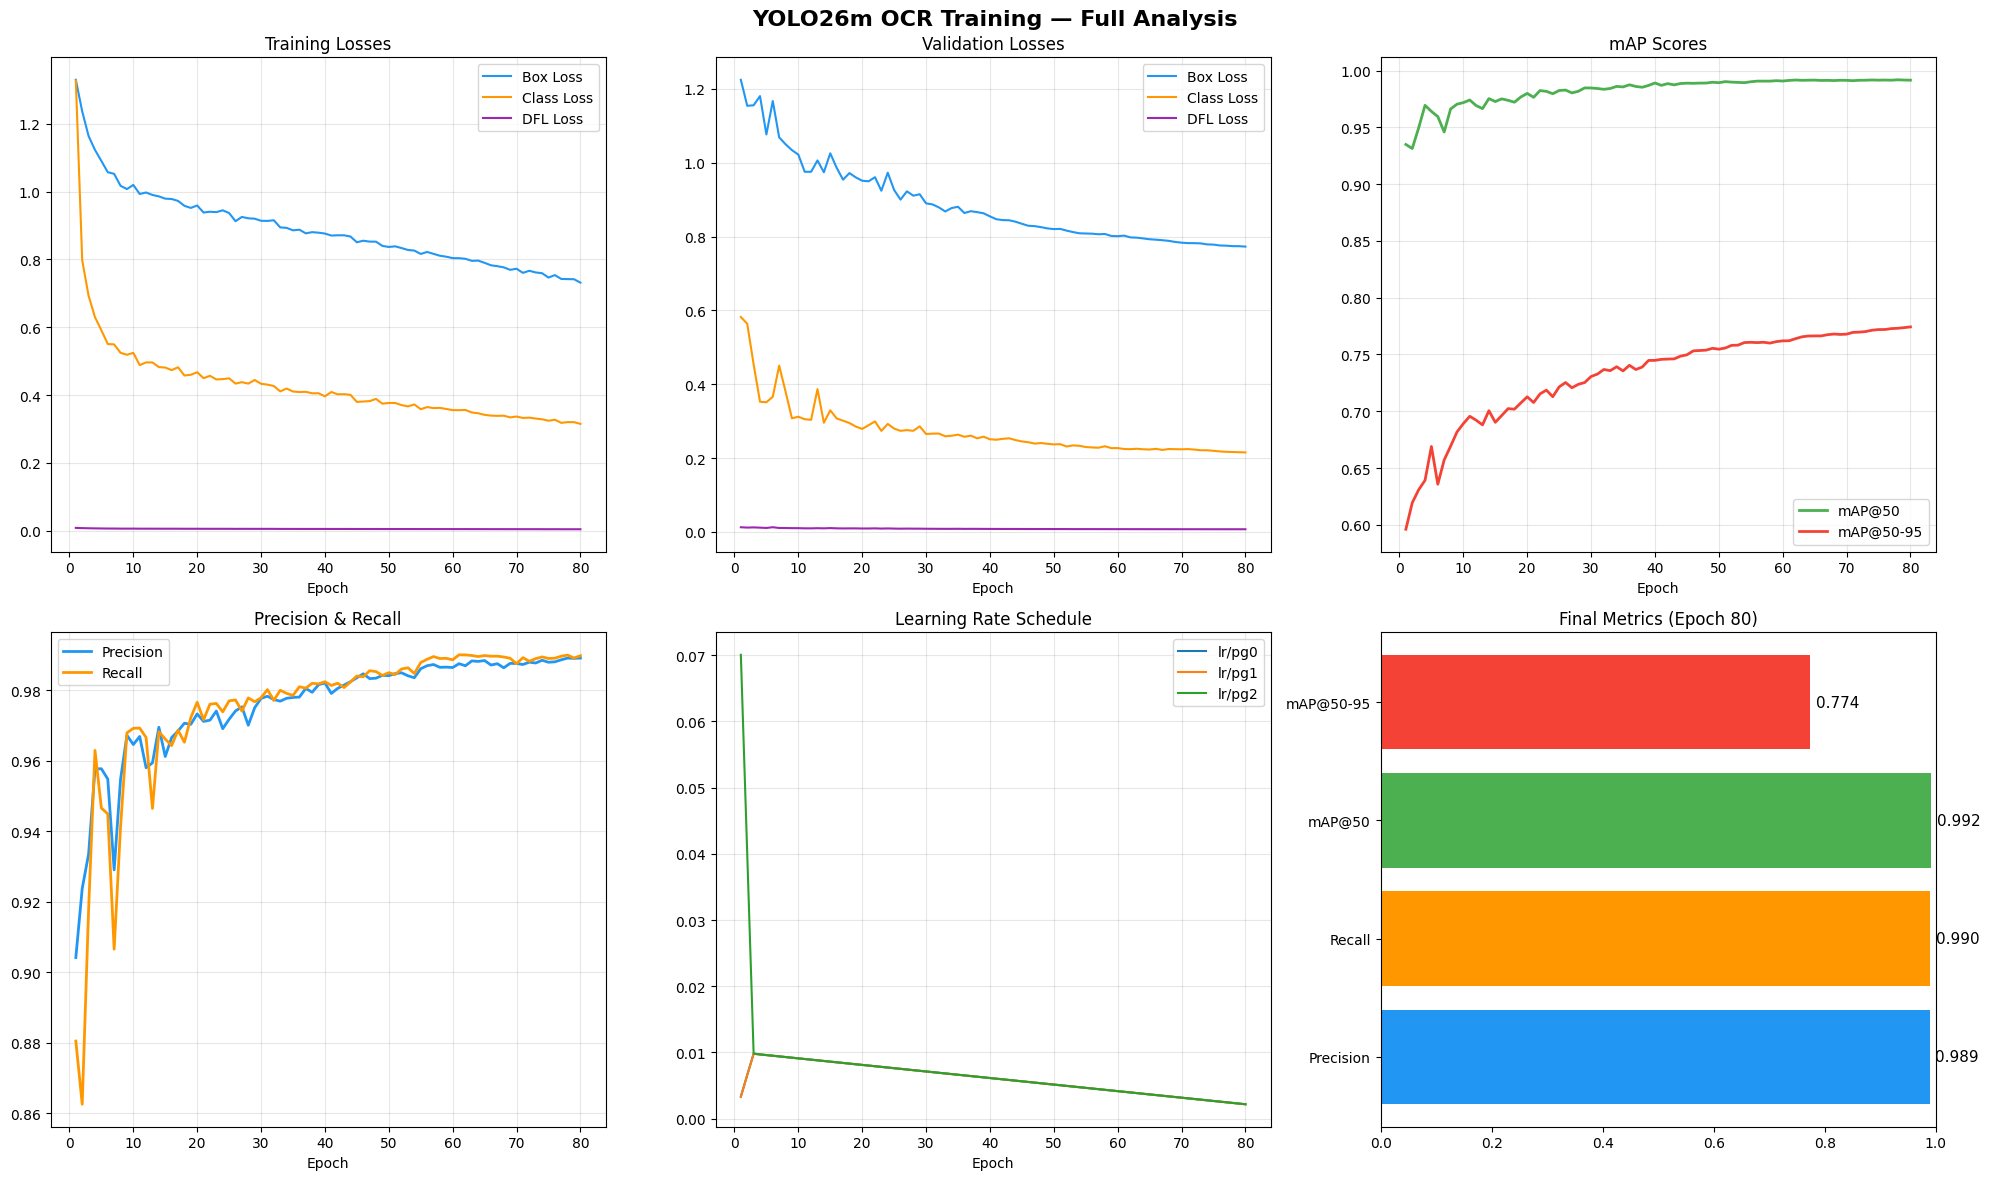


  FINAL TRAINING METRICS
        Precision: 0.9891
           Recall: 0.9898
           mAP@50: 0.9915
        mAP@50-95: 0.7742
       Best Epoch: 79
   Best mAP@50-95: 0.7742


In [20]:
# Parse training results CSV for custom plots
csv_path = os.path.join(results_dir, "results.csv")
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]
    epochs = df['epoch']

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))

    # Loss curves
    for col, color, title in [
        ('train/box_loss', '#2196F3', 'Box Loss'),
        ('train/cls_loss', '#FF9800', 'Class Loss'),
        ('train/dfl_loss', '#9C27B0', 'DFL Loss'),
    ]:
        if col in df.columns:
            axes[0][0].plot(epochs, df[col], label=title, color=color)
    axes[0][0].set_title('Training Losses')
    axes[0][0].set_xlabel('Epoch')
    axes[0][0].legend()
    axes[0][0].grid(alpha=0.3)

    for col, color, title in [
        ('val/box_loss', '#2196F3', 'Box Loss'),
        ('val/cls_loss', '#FF9800', 'Class Loss'),
        ('val/dfl_loss', '#9C27B0', 'DFL Loss'),
    ]:
        if col in df.columns:
            axes[0][1].plot(epochs, df[col], label=title, color=color)
    axes[0][1].set_title('Validation Losses')
    axes[0][1].set_xlabel('Epoch')
    axes[0][1].legend()
    axes[0][1].grid(alpha=0.3)

    # mAP curves
    for col, color, label in [
        ('metrics/mAP50(B)', '#4CAF50', 'mAP@50'),
        ('metrics/mAP50-95(B)', '#F44336', 'mAP@50-95'),
    ]:
        if col in df.columns:
            axes[0][2].plot(epochs, df[col], label=label, color=color, linewidth=2)
    axes[0][2].set_title('mAP Scores')
    axes[0][2].set_xlabel('Epoch')
    axes[0][2].legend()
    axes[0][2].grid(alpha=0.3)

    # Precision / Recall / F1
    for col, color, label in [
        ('metrics/precision(B)', '#2196F3', 'Precision'),
        ('metrics/recall(B)', '#FF9800', 'Recall'),
    ]:
        if col in df.columns:
            axes[1][0].plot(epochs, df[col], label=label, color=color, linewidth=2)
    axes[1][0].set_title('Precision & Recall')
    axes[1][0].set_xlabel('Epoch')
    axes[1][0].legend()
    axes[1][0].grid(alpha=0.3)

    # Learning rate
    lr_cols = [c for c in df.columns if 'lr' in c.lower()]
    for col in lr_cols:
        axes[1][1].plot(epochs, df[col], label=col)
    axes[1][1].set_title('Learning Rate Schedule')
    axes[1][1].set_xlabel('Epoch')
    axes[1][1].legend()
    axes[1][1].grid(alpha=0.3)

    # Final metrics summary bar
    final = df.iloc[-1]
    metric_names = ['metrics/precision(B)', 'metrics/recall(B)', 
                   'metrics/mAP50(B)', 'metrics/mAP50-95(B)']
    metric_labels = ['Precision', 'Recall', 'mAP@50', 'mAP@50-95']
    vals = [final.get(m, 0) for m in metric_names]
    colors = ['#2196F3', '#FF9800', '#4CAF50', '#F44336']
    axes[1][2].barh(metric_labels, vals, color=colors)
    axes[1][2].set_xlim(0, 1)
    axes[1][2].set_title(f'Final Metrics (Epoch {int(final["epoch"])})')
    for i, v in enumerate(vals):
        axes[1][2].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=11)

    plt.suptitle('YOLO26m OCR Training — Full Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(WORK_DIR, 'training_analysis.png'), dpi=150)
    plt.show()

    # Print final metrics
    print("\n" + "="*50)
    print("  FINAL TRAINING METRICS")
    print("="*50)
    for m, l in zip(metric_names, metric_labels):
        if m in df.columns:
            print(f"  {l:>15}: {df[m].iloc[-1]:.4f}")
    print(f"  {'Best Epoch':>15}: {df['metrics/mAP50-95(B)'].idxmax()}")
    print(f"  {'Best mAP@50-95':>15}: {df['metrics/mAP50-95(B)'].max():.4f}")

## 7. Per-Class Performance Analysis

In [21]:
# Run validation to get per-class metrics
val_results = best_model.val(data=yaml_path, split="test", verbose=True)

Ultralytics 8.4.49 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,378,750 parameters, 0 gradients, 68.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 29.9±36.4 MB/s, size: 30.4 KB)
val: Scanning /kaggle/input/datasets/marwanmesbah19/theoneandonlymesbah/characters_final/test/labels... 1335 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1335/1335 363.7it/s 3.7s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/marwanmesbah19/theoneandonlymesbah/characters_final/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 84/84 3.8it/s 22.3s0.3ss
                   all       1335       6474       0.99      0.992      0.992      0.774
                     0        143        155      0.926      0.894      0.937      0.373
                     1        357        447      0.989      0.991      0.994      0.745
               

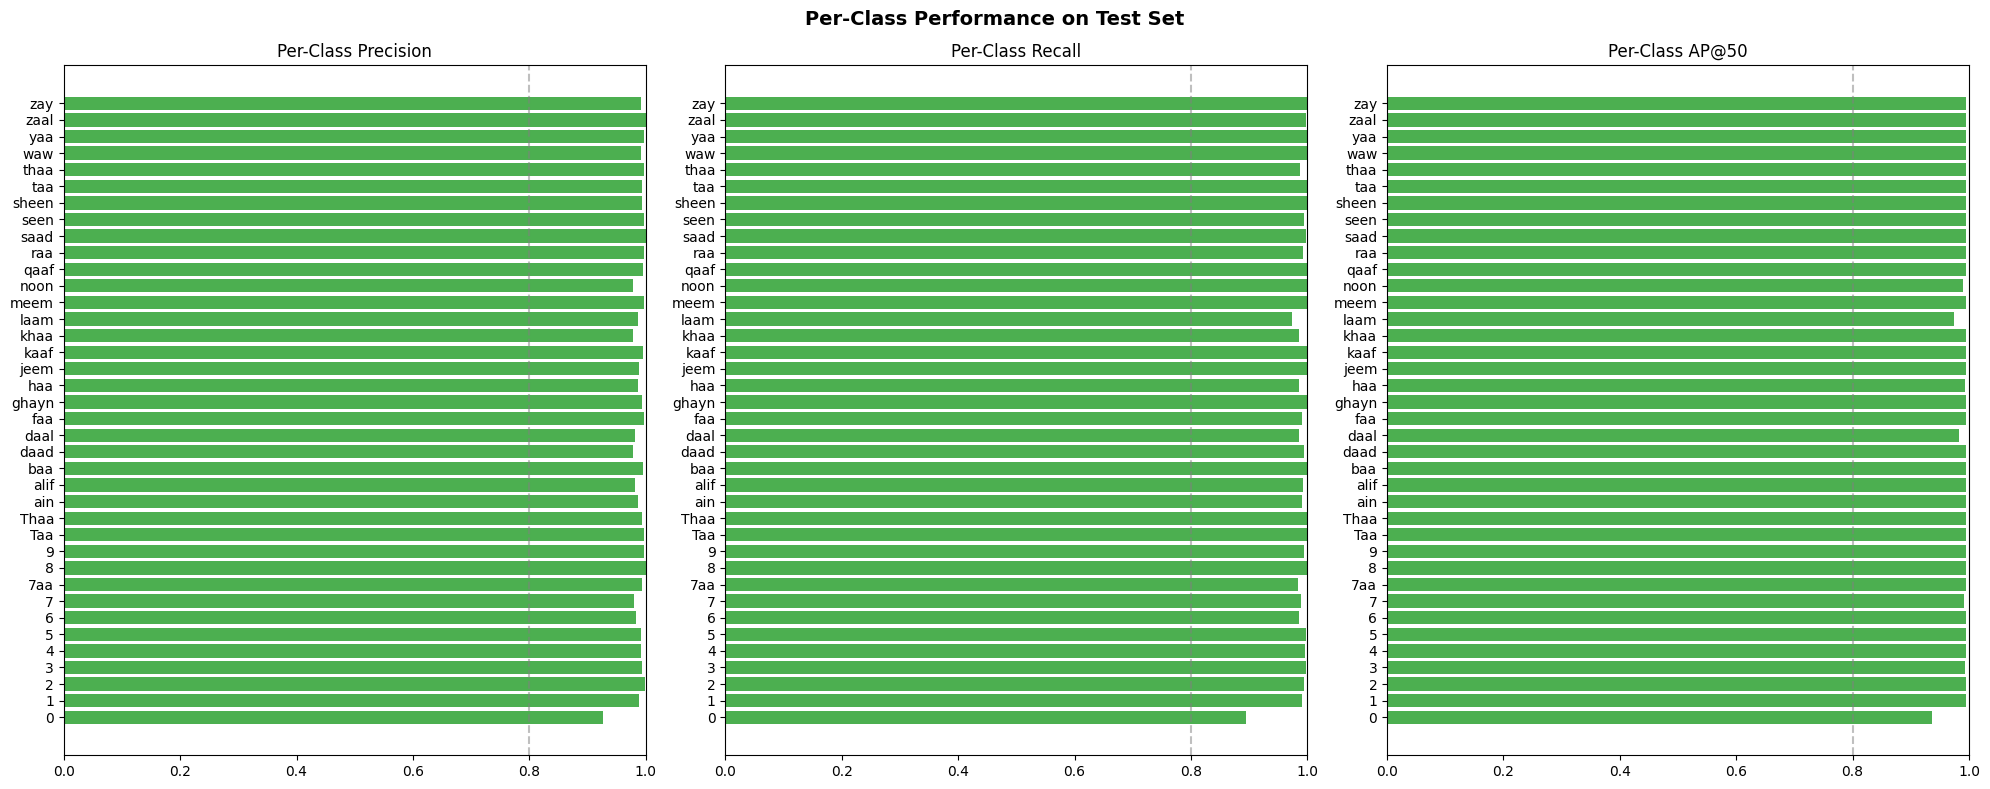


       Class  Precision     Recall      AP@50   AP@50-95
           0     0.9265     0.8944     0.9367     0.3728
           1     0.9888     0.9911     0.9941     0.7446
           2     0.9988     0.9944     0.9950     0.8245
           3     0.9943     0.9973     0.9939     0.8171
           4     0.9924     0.9961     0.9949     0.7941
           5     0.9923     0.9974     0.9947     0.8153
           6     0.9839     0.9854     0.9942     0.8237
           7     0.9792     0.9890     0.9908     0.8581
         7aa     0.9933     0.9833     0.9945     0.6303
           8     1.0000     0.9995     0.9950     0.8301
           9     0.9972     0.9949     0.9944     0.8338
         Taa     0.9973     1.0000     0.9950     0.8509
        Thaa     0.9934     1.0000     0.9950     0.7029
         ain     0.9863     0.9912     0.9949     0.8305
        alif     0.9810     0.9919     0.9950     0.7999
         baa     0.9946     1.0000     0.9950     0.8501
        daad     0.9791     0.

In [23]:
# Per-class metrics
per_class = val_results.box

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# Per-class precision
if hasattr(per_class, 'p') and per_class.p is not None:
    p_values = per_class.p.tolist() if hasattr(per_class.p, 'tolist') else per_class.p
    colors = ['#4CAF50' if v > 0.8 else '#FF9800' if v > 0.6 else '#F44336' for v in p_values]
    axes[0].barh(CLASS_NAMES[:len(p_values)], p_values, color=colors)
    axes[0].set_xlim(0, 1)
    axes[0].set_title('Per-Class Precision')
    axes[0].axvline(0.8, color='gray', linestyle='--', alpha=0.5)

# Per-class recall
if hasattr(per_class, 'r') and per_class.r is not None:
    r_values = per_class.r.tolist() if hasattr(per_class.r, 'tolist') else per_class.r
    colors = ['#4CAF50' if v > 0.8 else '#FF9800' if v > 0.6 else '#F44336' for v in r_values]
    axes[1].barh(CLASS_NAMES[:len(r_values)], r_values, color=colors)
    axes[1].set_xlim(0, 1)
    axes[1].set_title('Per-Class Recall')
    axes[1].axvline(0.8, color='gray', linestyle='--', alpha=0.5)

# Per-class mAP@50
if hasattr(per_class, 'ap50') and per_class.ap50 is not None:
    ap_values = per_class.ap50.tolist() if hasattr(per_class.ap50, 'tolist') else per_class.ap50
    colors = ['#4CAF50' if v > 0.8 else '#FF9800' if v > 0.6 else '#F44336' for v in ap_values]
    axes[2].barh(CLASS_NAMES[:len(ap_values)], ap_values, color=colors)
    axes[2].set_xlim(0, 1)
    axes[2].set_title('Per-Class AP@50')
    axes[2].axvline(0.8, color='gray', linestyle='--', alpha=0.5)

plt.suptitle('Per-Class Performance on Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'per_class_metrics.png'), dpi=150)
plt.show()

# Print per-class table
print("\n" + "="*70)
print(f"  {'Class':>10} {'Precision':>10} {'Recall':>10} {'AP@50':>10} {'AP@50-95':>10}")
print("="*70)
for i, name in enumerate(CLASS_NAMES[:len(p_values)]):
    p = p_values[i] if i < len(p_values) else 0
    r = r_values[i] if i < len(r_values) else 0
    ap50 = ap_values[i] if i < len(ap_values) else 0
    ap = per_class.ap.tolist()[i] if hasattr(per_class.ap, 'tolist') and i < len(per_class.ap) else 0
    flag = " ⚠️" if p < 0.7 or r < 0.7 else ""
    print(f"  {name:>10} {p:>10.4f} {r:>10.4f} {ap50:>10.4f} {ap:>10.4f}{flag}")
print("="*70)

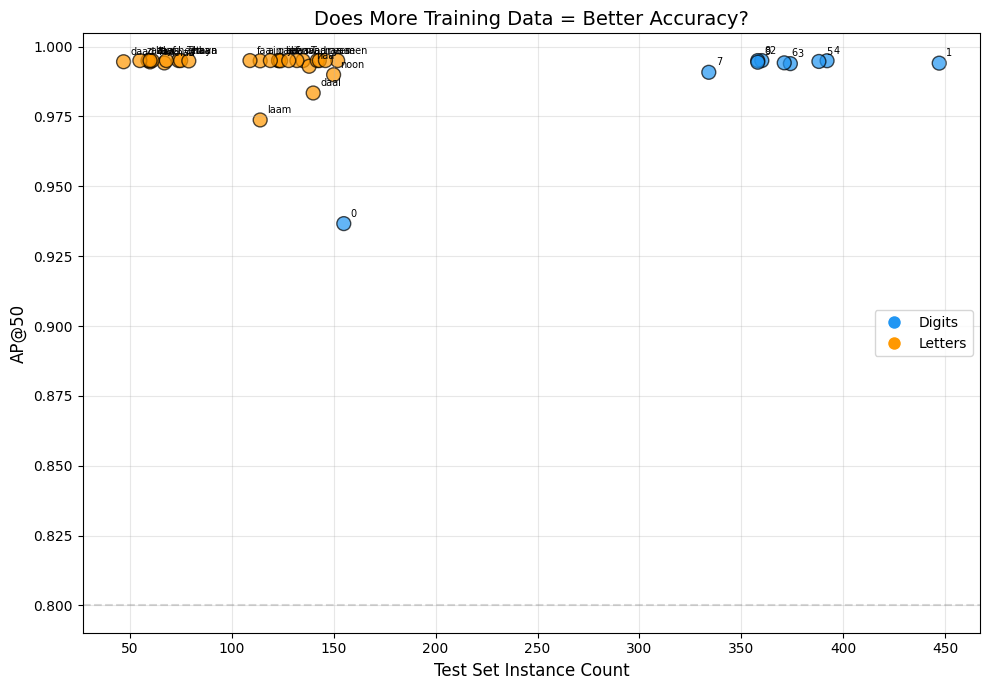

In [25]:
# Class performance vs instance count correlation
fig, ax = plt.subplots(figsize=(10, 7))
test_counts = Counter()
lbl_dir = os.path.join(DATASET_DIR, "test", "labels")
if os.path.exists(lbl_dir):
    for lbl_file in glob.glob(os.path.join(lbl_dir, "*.txt")):
        with open(lbl_file) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cid = int(parts[0])
                    if cid < len(CLASS_NAMES):
                        test_counts[CLASS_NAMES[cid]] += 1

if hasattr(per_class, 'ap50') and test_counts:
    counts = [test_counts.get(n, 0) for n in CLASS_NAMES[:len(ap_values)]]
    aps = ap_values[:len(counts)]
    
    scatter = ax.scatter(counts, aps, c=['#2196F3' if n.isdigit() else '#FF9800' for n in CLASS_NAMES[:len(counts)]],
                        s=100, alpha=0.7, edgecolors='black')
    for i, name in enumerate(CLASS_NAMES[:len(counts)]):
        ax.annotate(name, (counts[i], aps[i]), fontsize=7, 
                   xytext=(5, 5), textcoords='offset points')
    
    ax.set_xlabel('Test Set Instance Count', fontsize=12)
    ax.set_ylabel('AP@50', fontsize=12)
    ax.set_title('Does More Training Data = Better Accuracy?', fontsize=14)
    ax.axhline(0.8, color='gray', linestyle='--', alpha=0.3)
    ax.legend([plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#2196F3', markersize=10),
               plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF9800', markersize=10)],
              ['Digits', 'Letters'])
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(WORK_DIR, 'data_vs_accuracy.png'), dpi=150)
    plt.show()

## 8. Prediction Samples on Test Set

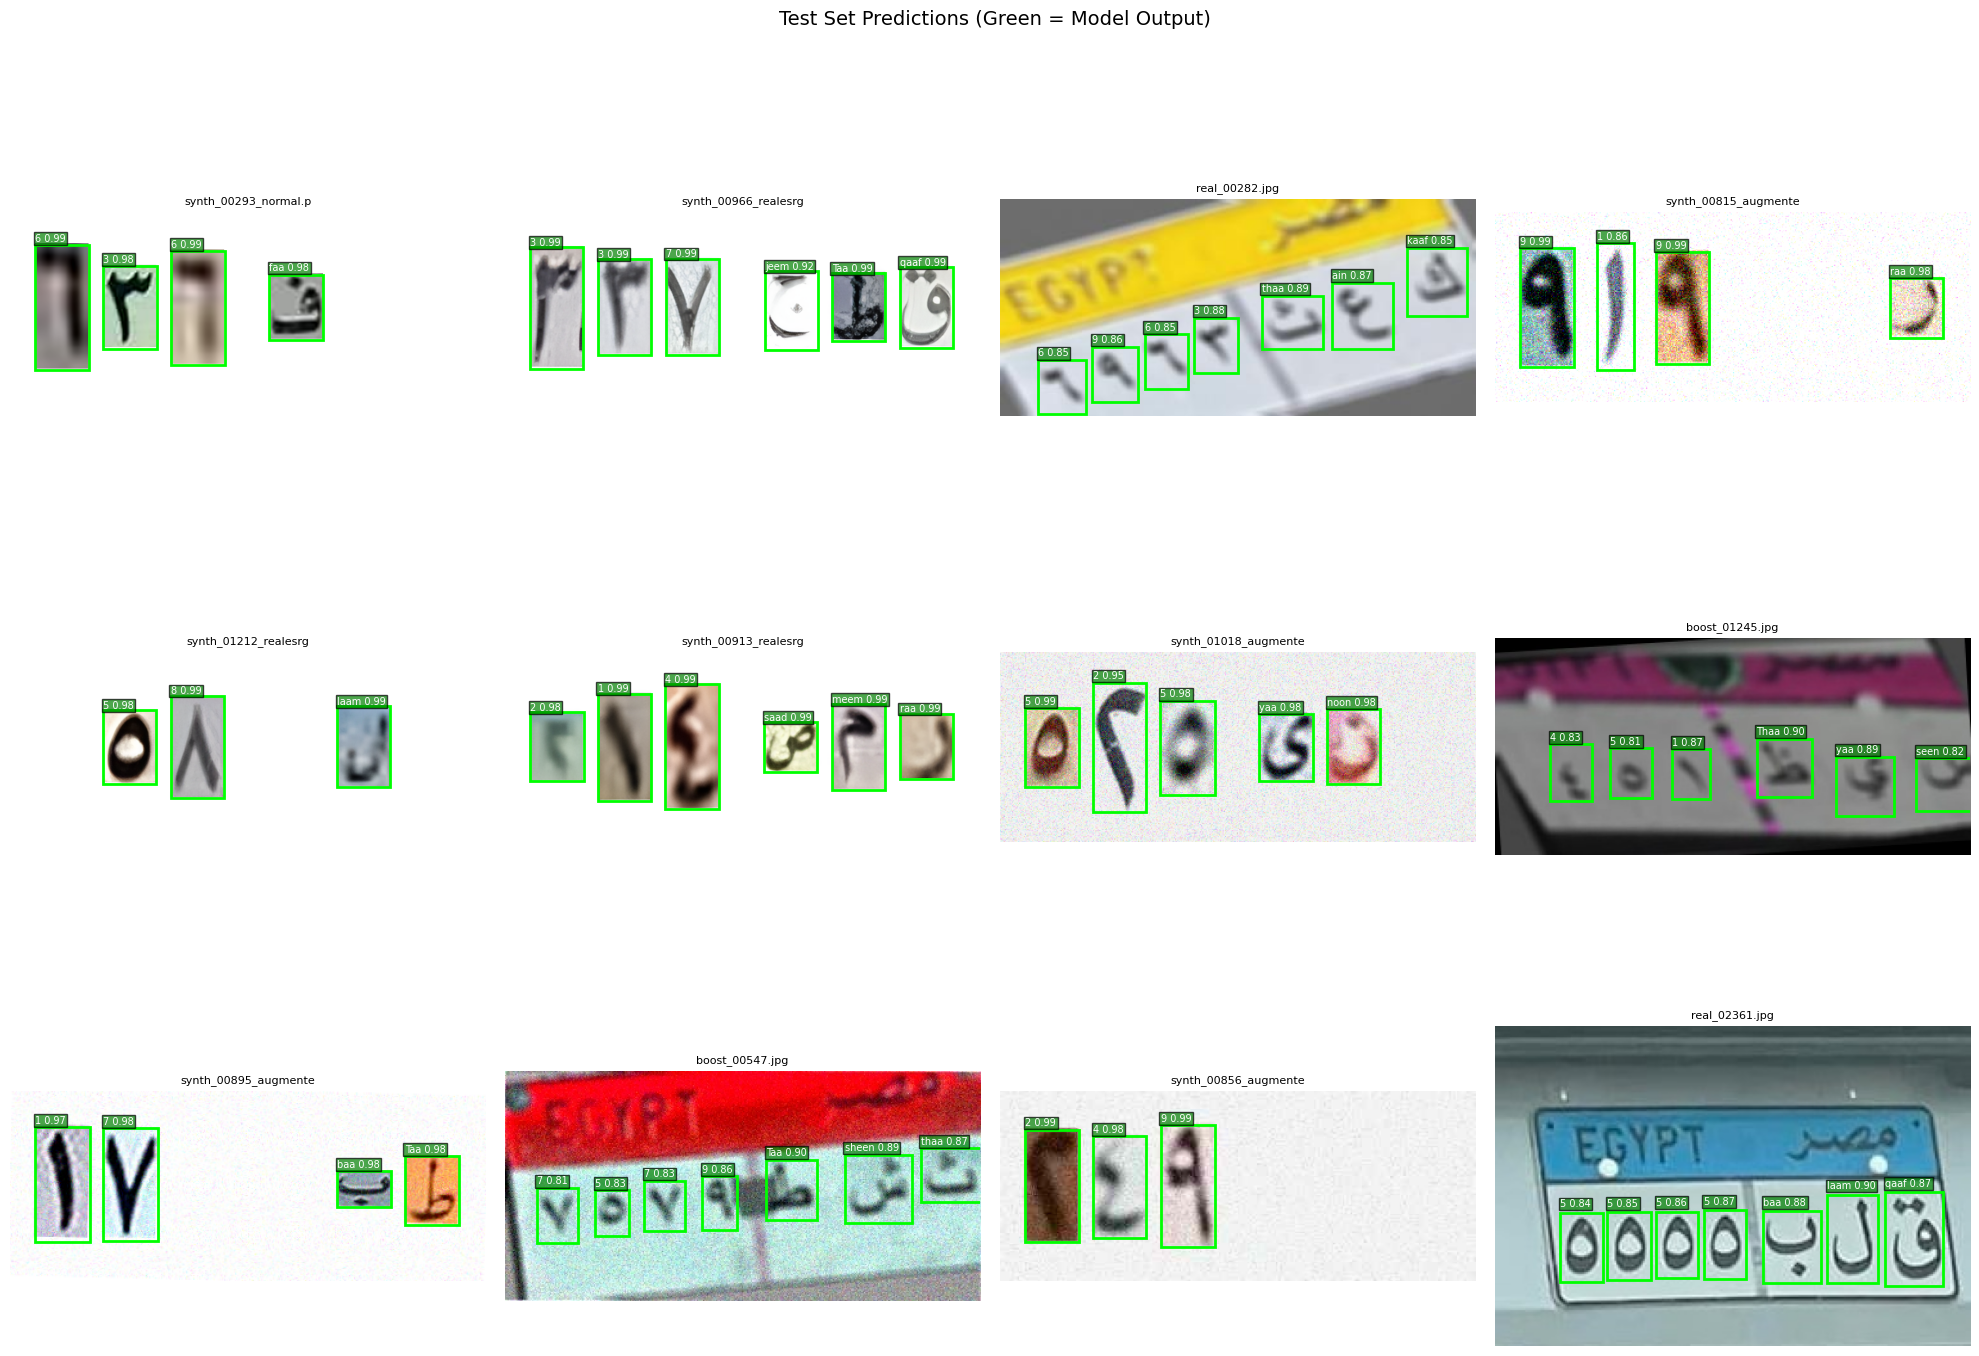

In [26]:
# Run predictions on test set and visualize
test_img_dir = os.path.join(DATASET_DIR, "test", "images")
test_imgs = glob.glob(os.path.join(test_img_dir, "*.*"))[:12]

if test_imgs:
    preds = best_model.predict(test_imgs, conf=0.25, save=False, verbose=False)

    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.flatten()

    for idx, (img_path, result) in enumerate(zip(test_imgs, preds)):
        img = Image.open(img_path)
        axes[idx].imshow(np.array(img))

        if result.boxes is not None:
            for box in result.boxes:
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                conf = box.conf[0].cpu().item()
                cls_id = int(box.cls[0].cpu().item())
                label = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else str(cls_id)
                
                rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                        linewidth=2, edgecolor='lime', facecolor='none')
                axes[idx].add_patch(rect)
                axes[idx].text(x1, y1 - 3, f"{label} {conf:.2f}", fontsize=7,
                              color='white', bbox=dict(facecolor='green', alpha=0.7, pad=1))

        axes[idx].set_title(Path(img_path).name[:20], fontsize=8)
        axes[idx].axis('off')

    for ax in axes[len(test_imgs):]:
        ax.axis('off')

    plt.suptitle('Test Set Predictions (Green = Model Output)', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(WORK_DIR, 'test_predictions.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 9. Export & Save

In [27]:
# Copy best weights to easily accessible location
import shutil

final_path = os.path.join(WORK_DIR, "yolo26m_car_plate_ocr_V2.pt")
shutil.copy2(best_model_path, final_path)
print(f"Model saved to: {final_path}")
print(f"File size: {os.path.getsize(final_path) / 1e6:.1f} MB")
print("\nDownload this file and place it in RADAR models/ directory")
print("Then update config.py: PLATE_OCR_MODEL_PATH = os.path.join(MODELS_DIR, 'yolo26m_car_plate_ocr_V2.pt')")

Model saved to: /kaggle/working/yolo26m_car_plate_ocr_V2.pt
File size: 175.5 MB

Download this file and place it in RADAR models/ directory
Then update config.py: PLATE_OCR_MODEL_PATH = os.path.join(MODELS_DIR, 'yolo26m_car_plate_ocr_V2.pt')


In [28]:
# Zip all presentation outputs for easy download
import shutil

output_dir = os.path.join(WORK_DIR, "yolo26m_V2_all_outputs")

# Copy presentation outputs, best model, and training results
os.makedirs(output_dir, exist_ok=True)

# Best model
if os.path.exists(best_model_path):
    shutil.copy2(best_model_path, os.path.join(output_dir, "yolo26m_car_plate_ocr_V2.pt"))
    print(f"Model: {os.path.getsize(best_model_path)/1e6:.1f} MB")

# Presentation images
pres_dir = os.path.join(WORK_DIR, "presentation_outputs")
if os.path.exists(pres_dir):
    for f in glob.glob(os.path.join(pres_dir, "*.*")):
        shutil.copy2(f, output_dir)

# Custom analysis plots
for f in glob.glob(os.path.join(WORK_DIR, "*.png")):
    shutil.copy2(f, output_dir)

# Training CSV results
csv_src = os.path.join(results_dir, "results.csv")
if os.path.exists(csv_src):
    shutil.copy2(csv_src, output_dir)

# Args.yaml
args_src = os.path.join(results_dir, "args.yaml")
if os.path.exists(args_src):
    shutil.copy2(args_src, output_dir)

# Zip it
shutil.make_archive(output_dir, 'zip', WORK_DIR, "yolo26m_V2_all_outputs")
print(f"\nAll outputs zipped to: {output_dir}.zip")
print(f"Files included:")
for f in sorted(os.listdir(output_dir)):
    size = os.path.getsize(os.path.join(output_dir, f))
    print(f"  {f} ({size/1e3:.0f} KB)" if size < 1e6 else f"  {f} ({size/1e6:.1f} MB)")


Model: 175.5 MB

All outputs zipped to: /kaggle/working/yolo26m_V2_all_outputs.zip
Files included:
  args.yaml (2 KB)
  bbox_analysis.png (91 KB)
  class_counts_per_split.png (81 KB)
  class_counts_total.png (84 KB)
  data_vs_accuracy.png (90 KB)
  extra_train_batch0.jpg (402 KB)
  extra_train_batch1.jpg (378 KB)
  extra_train_batch2.jpg (451 KB)
  image_dimensions.png (57 KB)
  labels.jpg (110 KB)
  per_class_metrics.png (91 KB)
  results.csv (10 KB)
  samples_test.png (1.9 MB)
  samples_train.png (1.1 MB)
  samples_val.png (1.3 MB)
  split_pie.png (65 KB)
  test_predictions.png (2.7 MB)
  training_analysis.png (299 KB)
  yolo26m_car_plate_ocr_V2.pt (175.5 MB)


In [30]:
# Zip the entire runs folder
runs_zip = os.path.join(WORK_DIR, "runs_backup")
shutil.make_archive(runs_zip, 'zip', WORK_DIR, "runs")
print(f"Runs folder zipped to: {runs_zip}.zip")
print(f"Size: {os.path.getsize(runs_zip + '.zip') / 1e6:.1f} MB")

Runs folder zipped to: /kaggle/working/runs_backup.zip
Size: 1438.9 MB
